# lgbm 모델 학습(베이스 코드)
- 이 코드를 통해 연구 진행

Mounted at /content/drive
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019814 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1189
[LightGBM] [Info] Number of data points in the train set: 358276, number of used features: 28
[LightGBM] [Info] Start training from score 95.126852
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's rmse: 13.4014	valid_0's l2: 179.597
LightGBM 결과
RMSE : 13.401396968560913
MAE  : 8.45042191184927
R2   : 0.9865183569553082


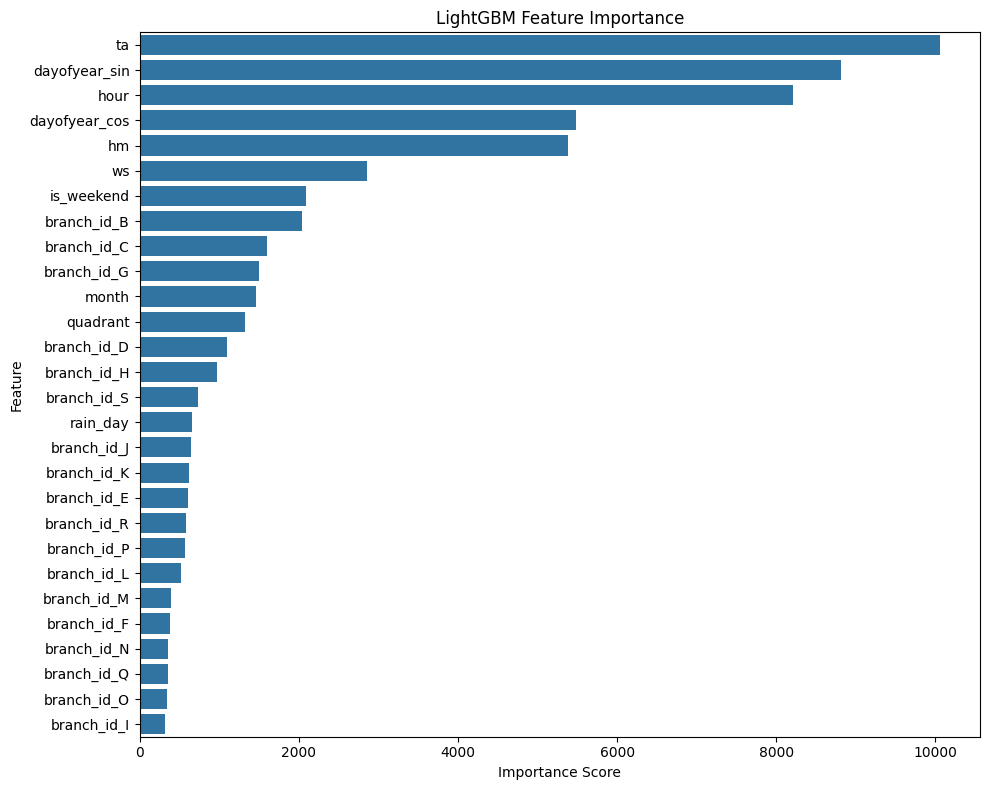

In [1]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import lightgbm
from google.colab import drive

# 드라이브 마운트
drive.mount('/content/drive')

# 경로 설정
PATH = "/content/drive/MyDrive/열수요예측/"
df_raw = pd.read_csv(PATH + "train_heat.csv")

# LGB 모델 함수 정의

# 이상치 처리
df = df_raw.copy()
df.columns = [col.split('.')[1] for col in df.columns]
for col in df.columns:
    df[col] = np.where(df[col] == -99, np.nan, df[col])
df['wd'] = np.where(df['wd'] < 0, np.nan, df['wd'])

# 필요없는 컬럼 제거
df.drop(['si', 'rn_hr1', 'ta_chi'], axis=1, inplace=True)

# 결측치 제거
df.dropna(inplace=True)

# 날짜 파싱 및 파생 변수 생성
df['tm'] = pd.to_datetime(df['tm'].astype(int), format='%Y%m%d%H')
df['month'] = df['tm'].dt.month
df['hour'] = df['tm'].dt.hour

# 요일 및 주말 여부
df['weekday'] = df['tm'].dt.dayofweek
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

# 계절성 변수 (1년 주기)
df['dayofyear'] = df['tm'].dt.dayofyear
df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)

# 더 이상 필요 없는 컬럼 제거
df.drop(['tm', 'weekday', 'dayofyear'], axis=1, inplace=True)

# 데이터 시작부터 현재 시점까지의 평균 온도
# df['ta_expanding_mean'] = df['ta'].expanding(min_periods=1).mean()
# # 데이터 시작부터 현재 시점까지의 습도 표준편차
# df['hm_expanding_std'] = df['hm'].expanding(min_periods=1).std().round(2)


# 바람 방향 범주화
df['quadrant'] = np.select(
    [
        (df['wd'] >= 315) | (df['wd'] < 45),   # 북서
        (df['wd'] >= 45) & (df['wd'] < 135),   # 북동
        (df['wd'] >= 135) & (df['wd'] < 225),  # 남동
        (df['wd'] >= 225) & (df['wd'] < 315)   # 남서
    ],
    [1, 2, 3, 4],
    default=-99  # 이미 -99는 존재하지 않음. 안전기작
)
df.drop('wd', axis=1, inplace=True)

# 강수량 이진화
df['rain_day'] = np.where(df['rn_day'] > 0, 1, 0)
df.drop('rn_day', axis=1, inplace=True)

# 원-핫 인코딩
df = pd.get_dummies(df, columns=['branch_id'], drop_first=True)

# x, y 분리
x = df.drop('heat_demand', axis=1)
y = df['heat_demand']

# 스케일링 및 분할
x_train, x_test, y_train, y_test = sk.model_selection.train_test_split(x, y, test_size=0.2, random_state=42)

LEARNING_RATE=0.05
# LightGBM 모델 정의
model = lightgbm.LGBMRegressor(
        n_estimators=2000,
        learning_rate=LEARNING_RATE,
        objective='regression',
    )


# 학습
model.fit(
    x_train, y_train,
    eval_set=[(x_test, y_test)],
    eval_metric='rmse',
    callbacks=[lightgbm.early_stopping(stopping_rounds=10)]
)
rmse = np.sqrt(sk.metrics.mean_squared_error(y_test, model.predict(x_test)))
# 평가 출력
print("LightGBM 결과")
print("RMSE :", rmse)
print("MAE  :", sk.metrics.mean_absolute_error(y_test, model.predict(x_test)))
print("R2   :", sk.metrics.r2_score(y_test, model.predict(x_test)))

# 중요도 추출 (split은 등장 횟수 기준, gain은 손실 감소량 기준)
importances = model.feature_importances_  # 기본은 split 기준
feature_names = x.columns

# 정리해서 시각화
importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 상위 20개 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x=importance_df, y=importance_df.index)
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 코드 결과 저장 코드
- 연구 진행시 훈련 함수 train_lgbm_model(df_raw)에 파생변수 추가하시면 예측 및 결과 저장 함수 def preprocess_for_prediction(df_test, train_features)에도 추가한 파생변수 넣어줘야합니다.

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. 기본 설정 및 데이터 로드 ---
PATH = "/content/drive/MyDrive/열수요예측/"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용할 디바이스: {DEVICE}")

try:
    df_raw = pd.read_csv(PATH + "train_heat.csv")
    df_test_raw = pd.read_csv(PATH + "test_heat.csv")
except FileNotFoundError:
    print(f"오류: '{PATH}' 경로에 'train_heat.csv' 또는 'test_heat.csv' 파일이 없습니다.")
    print("PATH 변수를 파일이 있는 실제 경로로 수정해주세요.")
    exit()

# --- 2. 데이터 전처리 함수 ---
def preprocess_data(df, is_train=True, scaler_x=None, scaler_y=None):
    """
    훈련 또는 테스트 데이터를 전처리합니다.
    - is_train=True: 훈련 데이터에 맞게 스케일러를 학습(fit)하고 적용합니다.
    - is_train=False: 이미 학습된 스케일러를 테스트 데이터에 적용합니다.
    """
    df_processed = df.copy()

    # 컬럼명 정리 (훈련/테스트 데이터에 따라 다름)
    if is_train:
        df_processed.columns = [col.split('.')[1] if '.' in col else col for col in df_processed.columns]
    else:
        new_column_names_map = {
            'TM': 'tm', 'branch_ID': 'branch_id', 'TA': 'ta', 'WD': 'wd',
            'WS': 'ws', 'RN_DAY': 'rn_day', 'RN_HR1': 'rn_hr1', 'HM': 'hm',
            'SI': 'si', 'ta_chi': 'ta_chi', 'heat_demand': 'heat_demand'
        }
        df_processed.rename(columns=new_column_names_map, inplace=True)

    # 결측값 처리
    for col in df_processed.columns:
        if col != 'tm':
            df_processed[col] = np.where(df_processed[col] == -99, np.nan, df_processed[col])
    if 'wd' in df_processed.columns:
        df_processed['wd'] = np.where(df_processed['wd'] < 0, np.nan, df_processed['wd'])

    # 불필요한 피처 제거
    cols_to_drop = ['si', 'rn_hr1', 'ta_chi']
    existing_cols_to_drop = [col for col in cols_to_drop if col in df_processed.columns]
    df_processed.drop(existing_cols_to_drop, axis=1, inplace=True)

    # 결측값 행 제거 (훈련 데이터에만 적용)
    if is_train:
        df_processed.dropna(inplace=True)

    # 날짜 파생 변수 생성
    df_processed['tm'] = pd.to_datetime(df_processed['tm'].astype(str), format='%Y%m%d%H')
    df_processed['month'] = df_processed['tm'].dt.month
    df_processed['hour'] = df_processed['tm'].dt.hour
    df_processed['is_weekend'] = df_processed['tm'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)
    df_processed['dayofyear_sin'] = np.sin(2 * np.pi * df_processed['tm'].dt.dayofyear / 365)
    df_processed['dayofyear_cos'] = np.cos(2 * np.pi * df_processed['tm'].dt.dayofyear / 365)
    df_processed.drop(['tm'], axis=1, inplace=True)

    # 풍향(wd) 변수 변환
    if 'wd' in df_processed.columns:
        df_processed['quadrant'] = np.select(
            [
                (df_processed['wd'] >= 315) | (df_processed['wd'] < 45),
                (df_processed['wd'] >= 45) & (df_processed['wd'] < 135),
                (df_processed['wd'] >= 135) & (df_processed['wd'] < 225),
                (df_processed['wd'] >= 225) & (df_processed['wd'] < 315)
            ],
            [1, 2, 3, 4], default=-99
        )
        df_processed.drop('wd', axis=1, inplace=True)

    # 강수(rn_day) 변수 변환
    if 'rn_day' in df_processed.columns:
        df_processed['rain_day'] = np.where(df_processed['rn_day'] > 0, 1, 0)
        df_processed.drop('rn_day', axis=1, inplace=True)

    # 범주형 변수(branch_id) 원-핫 인코딩
    if 'branch_id' in df_processed.columns:
        df_processed = pd.get_dummies(df_processed, columns=['branch_id'], drop_first=True)

    # 테스트 데이터의 결측값 채우기
    if not is_train:
        df_processed.fillna(method='ffill', inplace=True)
        df_processed.fillna(method='bfill', inplace=True)

    if is_train:
        # 훈련 데이터 분리
        X = df_processed.drop('heat_demand', axis=1)
        y = df_processed['heat_demand'].values.reshape(-1, 1) # 스케일러를 위해 2D 배열로 변환

        # 스케일러 학습 및 적용
        scaler_x = StandardScaler()
        scaler_y = StandardScaler()
        X_scaled = scaler_x.fit_transform(X)
        y_scaled = scaler_y.fit_transform(y)

        train_features = X.columns.tolist()
        return X_scaled, y_scaled, scaler_x, scaler_y, train_features
    else:
        # 훈련 데이터와 컬럼 순서 맞추기
        train_features = scaler_x.feature_names_in_ # 저장된 피처 이름 사용

        # 테스트 데이터에 없는 훈련용 컬럼 추가
        for col in train_features:
            if col not in df_processed.columns:
                df_processed[col] = 0

        # 훈련 데이터에 없는 테스트용 컬럼 제거
        for col in df_processed.columns:
            if col not in train_features:
                 df_processed.drop(col, axis=1, inplace=True)

        df_processed = df_processed[train_features] # 순서 정렬

        X_scaled = scaler_x.transform(df_processed)
        return X_scaled

# --- 3. 딥러닝 모델 정의 (MLP) ---
class HeatDemandModel(nn.Module):
    def __init__(self, input_size):
        super(HeatDemandModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # 출력층: 열 수요 예측값 1개
        )

    def forward(self, x):
        return self.layers(x)

# --- 4. 모델 훈련 함수 ---
def train_model(model, data_loader, epochs=50, lr=0.001):
    model.to(DEVICE)
    criterion = nn.MSELoss() # 손실 함수: 평균 제곱 오차
    optimizer = optim.Adam(model.parameters(), lr=lr) # 옵티마이저: Adam

    print("--- 모델 훈련 시작 ---")
    for epoch in range(epochs):
        model.train() # 훈련 모드
        epoch_loss = 0
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)

            # 경사 초기화
            optimizer.zero_grad()
            # 예측 및 손실 계산
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            # 역전파 및 가중치 업데이트
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(data_loader):.4f}")
    print("--- 모델 훈련 완료 ---")


# --- 5. 예측 함수 ---
def predict(model, data_loader, scaler_y):
    model.eval() # 평가 모드
    predictions = []
    with torch.no_grad(): # 경사 계산 비활성화
        for inputs in data_loader:
            inputs = inputs[0].to(DEVICE)
            outputs = model(inputs)
            predictions.extend(outputs.cpu().numpy())

    # 스케일링된 예측값을 원래 스케일로 복원
    predictions = scaler_y.inverse_transform(np.array(predictions).reshape(-1, 1))
    predictions[predictions < 0] = 0 # 0 미만 값은 0으로 처리
    return predictions.flatten()


# --- 메인 실행 로직 ---

# 1. 데이터 전처리 및 스케일링
x_train, y_train, scaler_x, scaler_y, train_features = preprocess_data(df_raw, is_train=True)
x_test = preprocess_data(df_test_raw, is_train=False, scaler_x=scaler_x)

print(f"훈련 데이터 피처 수: {x_train.shape[1]}")
print(f"테스트 데이터 피처 수: {x_test.shape[1]}")

# 2. PyTorch 데이터로더 생성
BATCH_SIZE = 128
train_dataset = TensorDataset(torch.FloatTensor(x_train), torch.FloatTensor(y_train))
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(torch.FloatTensor(x_test))
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 3. 모델 인스턴스화 및 훈련
input_size = x_train.shape[1]
model = HeatDemandModel(input_size)

train_model(model, train_loader, epochs=1000, lr=0.001)

# 4. 예측 수행
final_predictions = predict(model, test_loader, scaler_y)

# 5. 제출 파일 생성
print("\n--- 제출 파일 생성 ---")
submission_df = df_test_raw.copy()
submission_df['heat_demand'] = final_predictions

submission_filename = 'submission_deep_learning.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"'{submission_filename}' 파일이 성공적으로 생성되었습니다.")
print("생성된 파일 상위 5개 행:")
print(submission_df.head())

사용할 디바이스: cuda


<ipython-input-3-3241778778>:92: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_processed.fillna(method='ffill', inplace=True)
<ipython-input-3-3241778778>:93: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_processed.fillna(method='bfill', inplace=True)


훈련 데이터 피처 수: 28
테스트 데이터 피처 수: 28
--- 모델 훈련 시작 ---


KeyboardInterrupt: 

In [7]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import math
import warnings

warnings.filterwarnings('ignore')

# --- 1. 기본 설정 및 데이터 로드 ---
PATH = "/content/drive/MyDrive/열수요예측/" # 파일 경로를 실제 파일 위치에 맞게 수정해주세요.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용할 디바이스: {DEVICE}")

try:
    df_raw = pd.read_csv(PATH + "train_heat.csv")
    df_test_raw = pd.read_csv(PATH + "test_heat.csv")
    print("데이터 로드 성공!")
except FileNotFoundError:
    print(f"오류: '{PATH}' 경로에 'train_heat.csv' 또는 'test_heat.csv' 파일이 없습니다.")
    print("PATH 변수를 파일이 있는 실제 경로로 수정해주세요.")
    exit()

# --- 2. 데이터 전처리 함수 (강화된 버전) ---
def preprocess_data(df, is_train=True, scaler_x=None, scaler_y=None, train_features_columns=None):
    """
    훈련 또는 테스트 데이터를 전처리하고 고급 피처 엔지니어링을 수행합니다.
    - is_train=True: 훈련 데이터에 맞게 스케일러를 학습(fit)하고 적용하며, 피처 이름을 저장합니다.
    - is_train=False: 이미 학습된 스케일러를 테스트 데이터에 적용하고, 훈련 데이터의 피처 순서에 맞춥니다.
    """
    df_processed = df.copy()

    # 2.1. 컬럼명 정리 및 매핑
    if is_train:
        # 훈련 데이터셋 컬럼명 일관성 확보 (예: 'X.tm' -> 'tm')
        df_processed.columns = [col.split('.')[1] if '.' in col else col for col in df_processed.columns]
    else:
        # 테스트 데이터셋 컬럼명 매핑 (대소문자 및 일부 이름 불일치 처리)
        new_column_names_map = {
            'TM': 'tm', 'branch_ID': 'branch_id', 'TA': 'ta', 'WD': 'wd',
            'WS': 'ws', 'RN_DAY': 'rn_day', 'RN_HR1': 'rn_hr1', 'HM': 'hm',
            'SI': 'si', 'ta_chi': 'ta_chi', 'heat_demand': 'heat_demand'
        }
        df_processed.rename(columns=new_column_names_map, inplace=True)

    # 2.2. 결측값 및 이상치 처리 (-99는 NaN으로, wd 음수 값은 NaN으로)
    # 결측치 표기값(-99)을 NaN으로 변환
    df_processed.replace(-99.0, np.nan, inplace=True)
    if 'wd' in df_processed.columns:
        df_processed['wd'] = np.where(df_processed['wd'] < 0, np.nan, df_processed['wd']) # 음수 풍향 제거

    # 2.3. 날짜/시간 파생 변수 생성
    # 'tm' 컬럼이 문자열 형태일 경우 datetime으로 변환
    df_processed['tm'] = pd.to_datetime(df_processed['tm'].astype(str), format='%Y%m%d%H')

    df_processed['year'] = df_processed['tm'].dt.year # 연도
    df_processed['month'] = df_processed['tm'].dt.month # 월
    df_processed['day'] = df_processed['tm'].dt.day # 일
    df_processed['hour'] = df_processed['tm'].dt.hour # 시간
    df_processed['dayofweek'] = df_processed['tm'].dt.dayofweek # 요일 (월=0, 일=6)
    df_processed['weekofyear'] = df_processed['tm'].dt.isocalendar().week.astype(int) # 연중 몇 번째 주

    # 계절성 특성을 반영하기 위한 sin/cos 변환
    df_processed['hour_sin'] = np.sin(2 * np.pi * df_processed['hour'] / 24)
    df_processed['hour_cos'] = np.cos(2 * np.pi * df_processed['hour'] / 24)
    df_processed['month_sin'] = np.sin(2 * np.pi * df_processed['month'] / 12)
    df_processed['month_cos'] = np.cos(2 * np.pi * df_processed['month'] / 12)
    df_processed['dayofweek_sin'] = np.sin(2 * np.pi * df_processed['dayofweek'] / 7)
    df_processed['dayofweek_cos'] = np.cos(2 * np.pi * df_processed['dayofweek'] / 7)
    df_processed['dayofyear_sin'] = np.sin(2 * np.pi * df_processed['tm'].dt.dayofyear / 365.25) # 윤년 고려
    df_processed['dayofyear_cos'] = np.cos(2 * np.pi * df_processed['tm'].dt.dayofyear / 365.25) # 윤년 고려

    # 주말 여부 (토, 일)
    df_processed['is_weekend'] = df_processed['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

    # 시간대 구분 (예: 새벽, 오전, 오후, 저녁)
    df_processed['time_of_day'] = pd.cut(df_processed['hour'],
                                         bins=[-1, 6, 12, 18, 24],
                                         labels=['dawn', 'morning', 'afternoon', 'evening'],
                                         right=False)
    # time_of_day 컬럼을 원-핫 인코딩
    df_processed = pd.get_dummies(df_processed, columns=['time_of_day'], prefix='time')


    # 2.4. 날씨 관련 피처 엔지니어링

    # 풍향(wd)을 4분면으로 변환 및 One-Hot Encoding
    if 'wd' in df_processed.columns:
        df_processed['wind_quadrant'] = np.select(
            [
                (df_processed['wd'] >= 315) | (df_processed['wd'] < 45), # 북
                (df_processed['wd'] >= 45) & (df_processed['wd'] < 135), # 동
                (df_processed['wd'] >= 135) & (df_processed['wd'] < 225), # 남
                (df_processed['wd'] >= 225) & (df_processed['wd'] < 315)  # 서
            ],
            ['N', 'E', 'S', 'W'],
            default='NaN' # 수정: 문자열 'NaN'으로 기본값 설정
        )
        # 문자열 'NaN'을 실제 np.nan으로 다시 변환
        df_processed['wind_quadrant'].replace('NaN', np.nan, inplace=True)

        # One-Hot Encoding
        # drop_first=True로 한 개의 더미 변수를 제거하여 다중공선성 방지
        df_processed = pd.get_dummies(df_processed, columns=['wind_quadrant'], prefix='wd', drop_first=True)
        df_processed.drop('wd', axis=1, inplace=True) # 원본 풍향 컬럼 제거


    # 강수(rn_day) 변수: 비 온 여부 (0: 비 안 옴, 1: 비 옴)
    if 'rn_day' in df_processed.columns:
        df_processed['is_rain'] = np.where(df_processed['rn_day'] > 0, 1, 0)
        df_processed.drop('rn_day', axis=1, inplace=True)

    # 습도(hm)와 기온(ta) 조합 피처: 불쾌지수와 유사
    if 'hm' in df_processed.columns and 'ta' in df_processed.columns:
        df_processed['ta_hm_interaction'] = df_processed['ta'] * df_processed['hm']

    # 풍속(ws)과 기온(ta) 조합 피처: 체감온도와 유사
    if 'ws' in df_processed.columns and 'ta' in df_processed.columns:
        # 간이 체감온도 계산 (풍속이 0이거나 낮을 때 체감온도 변화가 미미하므로, 조건부로 적용도 가능)
        df_processed['wind_chill_approx'] = df_processed['ta'] - (0.7 * df_processed['ws'])

    # 일사량(si)과 기온(ta) 조합 피처: 열 획득 고려
    if 'si' in df_processed.columns and 'ta' in df_processed.columns:
        df_processed['solar_heat_gain'] = df_processed['si'] * df_processed['ta']

    # 2.5. 체감온도(ta_chi), 일사량(si), 시간 강수량(rn_hr1) 활용
    # 이 컬럼들은 기존 코드에서 제거되었지만, 데이터 설명을 보면 유의미할 수 있습니다.
    # 결측치가 많거나 데이터 품질 이슈가 있을 수 있어 신중하게 접근합니다.
    # 여기서는 유지하되, 결측치 처리에 집중합니다.
    # df_processed.drop(['si', 'rn_hr1', 'ta_chi'], axis=1, inplace=True) # 기존 제거 로직 (이번에는 제거하지 않음)


    # 2.6. 범주형 변수(branch_id) 원-핫 인코딩
    # 컬럼이 존재하는지 확인 후 get_dummies 적용
    if 'branch_id' in df_processed.columns: # <-- 이 부분이 수정되었습니다.
        # 주의: 훈련/테스트 데이터에 모든 branch_id가 동일하게 존재하지 않을 수 있습니다.
        # 이를 위해 모든 데이터셋에서 고유한 branch_id 목록을 미리 만들어서
        # `categories` 인자로 전달하는 것이 가장 견고합니다.
        # 하지만 현재 단계에서는 `pd.get_dummies`가 자동으로 처리하도록 둡니다.
        # 나중에 테스트 데이터셋에서 없는 컬럼은 0으로 채워질 것입니다.
        df_processed = pd.get_dummies(df_processed, columns=['branch_id'], prefix='branch', dummy_na=False)


    # 2.7. 'tm' 및 임시 컬럼 제거
    df_processed.drop(['tm', 'year', 'day', 'dayofweek', 'weekofyear'], axis=1, inplace=True, errors='ignore')

    # 2.8. 결측값 채우기 (훈련 데이터는 제거, 테스트 데이터는 보간)
    if is_train:
        # 훈련 데이터는 결측값이 있는 행 제거
        # 열 수요(heat_demand)가 NaN인 행도 제거해야 함.
        initial_rows = df_processed.shape[0]
        df_processed.dropna(inplace=True)
        print(f"훈련 데이터 결측값 제거 후 {initial_rows} -> {df_processed.shape[0]} 행 감소")
    else:
        # 테스트 데이터는 선형 보간 (ffill, bfill 보다는 선형 보간이 더 합리적일 수 있음)
        df_processed.interpolate(method='linear', limit_direction='both', inplace=True)
        # 그래도 남은 NaN이 있다면 ffill, bfill로 채움 (극히 드문 경우)
        df_processed.fillna(method='ffill', inplace=True)
        df_processed.fillna(method='bfill', inplace=True)
        print("테스트 데이터 결측값 선형 보간 완료.")


    # 2.9. 특성(X)과 타겟(y) 분리 및 스케일링
    if is_train:
        X = df_processed.drop('heat_demand', axis=1)
        y = df_processed['heat_demand'].values.reshape(-1, 1) # 스케일러를 위해 2D 배열로 변환

        scaler_x = StandardScaler()
        scaler_y = StandardScaler()

        X_scaled = scaler_x.fit_transform(X)
        y_scaled = scaler_y.fit_transform(y)

        train_features_columns = X.columns.tolist() # 훈련 데이터의 피처 이름 저장

        return X_scaled, y_scaled, scaler_x, scaler_y, train_features_columns
    else:
        # 테스트 데이터셋에 훈련 데이터셋의 모든 컬럼이 있는지 확인 및 정렬
        # 훈련 데이터에 존재하지만 테스트 데이터에 없는 원-핫 인코딩 컬럼 처리
        # (예: 특정 branch_id가 테스트 데이터에만 있거나 훈련 데이터에만 있을 경우)

        # 훈련 시 학습된 피처 컬럼 목록을 사용하여 테스트 데이터셋을 정렬하고 없는 컬럼은 0으로 채움
        for col in train_features_columns:
            if col not in df_processed.columns:
                df_processed[col] = 0.0 # float 형식으로 추가

        # 훈련 데이터셋에 없는 테스트 데이터셋 컬럼 제거
        for col in df_processed.columns:
            if col not in train_features_columns and col != 'heat_demand': # heat_demand는 타겟이므로 제외
                df_processed.drop(col, axis=1, inplace=True)

        df_processed = df_processed[train_features_columns] # 순서 정렬

        X_scaled = scaler_x.transform(df_processed)
        return X_scaled

# --- 3. 딥러닝 모델 정의 (강화된 MLP) ---
class HeatDemandModel(nn.Module):
    def __init__(self, input_size):
        super(HeatDemandModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 256), # 뉴런 수 증가
            nn.BatchNorm1d(256),       # 배치 정규화 추가
            nn.LeakyReLU(),            # LeakyReLU 활성화 함수 (ReLU보다 더 유연)
            nn.Dropout(0.3),           # 드롭아웃으로 과적합 방지

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(),
            nn.Dropout(0.2), # 마지막 드롭아웃 비율은 조금 낮춤

            nn.Linear(64, 32),
            nn.LeakyReLU(),

            nn.Linear(32, 1) # 출력층: 열 수요 예측값 1개 (회귀)
        )

    def forward(self, x):
        return self.layers(x)

# --- 4. 모델 훈련 함수 ---
def train_model(model, train_loader, epochs=1000, lr=0.001):
    model.to(DEVICE)
    criterion = nn.MSELoss() # 손실 함수: 평균 제곱 오차
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5) # L2 규제 (weight_decay) 추가

    print("--- 모델 훈련 시작 ---")
    for epoch in range(epochs):
        model.train() # 훈련 모드
        epoch_loss = 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)

            # 경사 초기화
            optimizer.zero_grad()
            # 예측 및 손실 계산
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            # 역전파 및 가중치 업데이트
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        if (epoch + 1) % 50 == 0 or epoch == 0: # 50 에포크마다, 그리고 첫 에포크에 출력
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.4f}")
    print("--- 모델 훈련 완료 ---")


# --- 5. 예측 함수 ---
def predict(model, data_loader, scaler_y):
    model.eval() # 평가 모드
    predictions = []
    with torch.no_grad(): # 경사 계산 비활성화 (메모리 절약, 속도 향상)
        for inputs in data_loader:
            inputs = inputs[0].to(DEVICE) # TensorDataset에서 피처만 가져옴
            outputs = model(inputs)
            predictions.extend(outputs.cpu().numpy())

    # 스케일링된 예측값을 원래 스케일로 복원
    predictions = scaler_y.inverse_transform(np.array(predictions).reshape(-1, 1))
    predictions[predictions < 0] = 0 # 열 수요는 음수가 될 수 없으므로 0 미만 값은 0으로 처리
    return predictions.flatten() # 1차원 배열로 반환


# --- 메인 실행 로직 ---

print("\n--- 데이터 전처리 시작 ---")
# 1. 데이터 전처리 및 스케일링
# 훈련 데이터 전처리 시 scaler_x, scaler_y, train_features_columns를 반환받음
x_train, y_train, scaler_x, scaler_y, train_features = preprocess_data(df_raw, is_train=True)

# 테스트 데이터 전처리 시 훈련 데이터에서 학습된 scaler_x, scaler_y, train_features_columns 사용
x_test = preprocess_data(df_test_raw, is_train=False, scaler_x=scaler_x, train_features_columns=train_features)

print(f"최종 훈련 데이터 피처 수: {x_train.shape[1]}")
print(f"최종 테스트 데이터 피처 수: {x_test.shape[1]}")

# 2. PyTorch 데이터로더 생성
BATCH_SIZE = 256 # 배치 사이즈 증가 (GPU 메모리 허용 범위 내에서)
train_dataset = TensorDataset(torch.FloatTensor(x_train), torch.FloatTensor(y_train))
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(torch.FloatTensor(x_test))
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 3. 모델 인스턴스화 및 훈련
input_size = x_train.shape[1]
model = HeatDemandModel(input_size)
print(f"\n모델 아키텍처:\n{model}")

# 훈련 에포크 및 학습률 조정 (과적합 방지를 위해 학습률은 너무 높지 않게)
train_model(model, train_loader, epochs=1500, lr=0.0005) # 에포크를 더 늘리고 학습률을 미세 조정

# 4. 예측 수행
print("\n--- 테스트 데이터 예측 시작 ---")
final_predictions = predict(model, test_loader, scaler_y)

# 5. 제출 파일 생성
print("\n--- 제출 파일 생성 ---")
submission_df = df_test_raw.copy()
submission_df['heat_demand'] = final_predictions

submission_filename = 'submission_deep_learning_advanced.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"'{submission_filename}' 파일이 성공적으로 생성되었습니다.")
print("생성된 파일 상위 5개 행:")
print(submission_df.head())

# (선택 사항) 훈련 데이터에 대한 예측 및 RMSE 계산 (과적합 확인용)
# 훈련 데이터 로더는 섞여 있으므로, 순서를 유지하는 별도 로더 또는 직접 예측 필요
# 여기서는 간단히 훈련 데이터를 다시 TensorDataset으로 만들고 평가
train_eval_dataset = TensorDataset(torch.FloatTensor(x_train))
train_eval_loader = DataLoader(dataset=train_eval_dataset, batch_size=BATCH_SIZE, shuffle=False)
train_predictions_scaled = predict(model, train_eval_loader, scaler_y)

# 훈련 데이터의 실제 값 (비-스케일링된)
y_train_original = scaler_y.inverse_transform(y_train)

# 훈련 데이터 RMSE 계산
rmse_train = math.sqrt(mean_squared_error(y_train_original, train_predictions_scaled))
print(f"\n훈련 데이터 RMSE (과적합 지표): {rmse_train:.4f}")

사용할 디바이스: cuda
데이터 로드 성공!

--- 데이터 전처리 시작 ---
훈련 데이터 결측값 제거 후 499301 -> 236232 행 감소
테스트 데이터 결측값 선형 보간 완료.
최종 훈련 데이터 피처 수: 47
최종 테스트 데이터 피처 수: 47

모델 아키텍처:
HeatDemandModel(
  (layers): Sequential(
    (0): Linear(in_features=47, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.01)
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): LeakyReLU(negative_slope=0.01)
    (14): 

In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split # 검증 세트 분리용
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import math
import warnings

warnings.filterwarnings('ignore')

# --- 1. 기본 설정 및 데이터 로드 ---
PATH = "/content/drive/MyDrive/열수요예측/" # 파일 경로를 실제 파일 위치에 맞게 수정해주세요.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용할 디바이스: {DEVICE}")

try:
    df_raw = pd.read_csv(PATH + "train_heat.csv")
    df_test_raw = pd.read_csv(PATH + "test_heat.csv")
    print("데이터 로드 성공!")
except FileNotFoundError:
    print(f"오류: '{PATH}' 경로에 'train_heat.csv' 또는 'test_heat.csv' 파일이 없습니다.")
    print("PATH 변수를 파일이 있는 실제 경로로 수정해주세요.")
    exit()

# --- 2. 데이터 전처리 함수 (강화된 버전) ---
def preprocess_data(df, is_train=True, scaler_x=None, scaler_y=None, train_features_columns=None):
    """
    훈련 또는 테스트 데이터를 전처리하고 고급 피처 엔지니어링을 수행합니다.
    - is_train=True: 훈련 데이터에 맞게 스케일러를 학습(fit)하고 적용하며, 피처 이름을 저장합니다.
    - is_train=False: 이미 학습된 스케일러를 테스트 데이터에 적용하고, 훈련 데이터의 피처 순서에 맞춥니다.
    """
    df_processed = df.copy()

    # 2.1. 컬럼명 정리 및 매핑
    if is_train:
        df_processed.columns = [col.split('.')[1] if '.' in col else col for col in df_processed.columns]
    else:
        new_column_names_map = {
            'TM': 'tm', 'branch_ID': 'branch_id', 'TA': 'ta', 'WD': 'wd',
            'WS': 'ws', 'RN_DAY': 'rn_day', 'RN_HR1': 'rn_hr1', 'HM': 'hm',
            'SI': 'si', 'ta_chi': 'ta_chi', 'heat_demand': 'heat_demand'
        }
        df_processed.rename(columns=new_column_names_map, inplace=True)

    # 2.2. 결측값 및 이상치 처리 (-99는 NaN으로, wd 음수 값은 NaN으로)
    df_processed.replace(-99.0, np.nan, inplace=True)
    if 'wd' in df_processed.columns:
        df_processed['wd'] = np.where(df_processed['wd'] < 0, np.nan, df_processed['wd']) # 음수 풍향 제거

    # 2.3. 날짜/시간 파생 변수 생성
    df_processed['tm'] = pd.to_datetime(df_processed['tm'].astype(str), format='%Y%m%d%H')

    df_processed['year'] = df_processed['tm'].dt.year
    df_processed['month'] = df_processed['tm'].dt.month
    df_processed['day'] = df_processed['tm'].dt.day
    df_processed['hour'] = df_processed['tm'].dt.hour
    df_processed['dayofweek'] = df_processed['tm'].dt.dayofweek
    df_processed['weekofyear'] = df_processed['tm'].dt.isocalendar().week.astype(int)

    df_processed['hour_sin'] = np.sin(2 * np.pi * df_processed['hour'] / 24)
    df_processed['hour_cos'] = np.cos(2 * np.pi * df_processed['hour'] / 24)
    df_processed['month_sin'] = np.sin(2 * np.pi * df_processed['month'] / 12)
    df_processed['month_cos'] = np.cos(2 * np.pi * df_processed['month'] / 12)
    df_processed['dayofweek_sin'] = np.sin(2 * np.pi * df_processed['dayofweek'] / 7)
    df_processed['dayofweek_cos'] = np.cos(2 * np.pi * df_processed['dayofweek'] / 7)
    df_processed['dayofyear_sin'] = np.sin(2 * np.pi * df_processed['tm'].dt.dayofyear / 365.25)
    df_processed['dayofyear_cos'] = np.cos(2 * np.pi * df_processed['tm'].dt.dayofyear / 365.25)

    df_processed['is_weekend'] = df_processed['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

    df_processed['time_of_day'] = pd.cut(df_processed['hour'],
                                         bins=[-1, 6, 12, 18, 24],
                                         labels=['dawn', 'morning', 'afternoon', 'evening'],
                                         right=False)
    df_processed = pd.get_dummies(df_processed, columns=['time_of_day'], prefix='time')


    # 2.4. 날씨 관련 피처 엔지니어링

    if 'wd' in df_processed.columns:
        df_processed['wind_quadrant'] = np.select(
            [
                (df_processed['wd'] >= 315) | (df_processed['wd'] < 45),
                (df_processed['wd'] >= 45) & (df_processed['wd'] < 135),
                (df_processed['wd'] >= 135) & (df_processed['wd'] < 225),
                (df_processed['wd'] >= 225) & (df_processed['wd'] < 315)
            ],
            ['N', 'E', 'S', 'W'],
            default='NaN'
        )
        df_processed['wind_quadrant'].replace('NaN', np.nan, inplace=True)
        df_processed = pd.get_dummies(df_processed, columns=['wind_quadrant'], prefix='wd', drop_first=True)
        df_processed.drop('wd', axis=1, inplace=True)

    if 'rn_day' in df_processed.columns:
        df_processed['is_rain'] = np.where(df_processed['rn_day'] > 0, 1, 0)
        df_processed.drop('rn_day', axis=1, inplace=True)

    if 'hm' in df_processed.columns and 'ta' in df_processed.columns:
        df_processed['ta_hm_interaction'] = df_processed['ta'] * df_processed['hm']

    if 'ws' in df_processed.columns and 'ta' in df_processed.columns:
        df_processed['wind_chill_approx'] = df_processed['ta'] - (0.7 * df_processed['ws'])

    if 'si' in df_processed.columns and 'ta' in df_processed.columns:
        df_processed['solar_heat_gain'] = df_processed['si'] * df_processed['ta']

    # 2.5. 체감온도(ta_chi), 일사량(si), 시간 강수량(rn_hr1) 활용 및 결측치 고급 처리
    # 'branch_id'가 존재하고, 아직 원-핫 인코딩되기 전인 경우에만 이 로직을 사용
    columns_to_impute = ['ta_chi', 'si', 'rn_hr1']

    # 임시 컬럼 생성 및 데이터 타입 확인
    # 'month'와 'hour'는 이미 위에서 파생변수로 생성되어 있으므로 재할당 불필요
    # 'branch_id'는 drop_first=True가 적용된 get_dummies 이전에 이 로직이 실행되어야 함

    if 'branch_id' in df_processed.columns:
        temp_df_for_imputation = df_processed[['branch_id', 'month', 'hour'] + [col for col in columns_to_impute if col in df_processed.columns]].copy()

        for col in columns_to_impute:
            if col in temp_df_for_imputation.columns:
                if is_train:
                    # 훈련 데이터에서 그룹별 평균 계산 및 저장 (실제로는 저장해두고 테스트 시 사용)
                    global_mean = temp_df_for_imputation[col].mean()
                    temp_df_for_imputation[col] = temp_df_for_imputation.groupby(['branch_id', 'month', 'hour'])[col].transform(lambda x: x.fillna(x.mean()))
                    temp_df_for_imputation[col].fillna(global_mean, inplace=True)
                else:
                    # 테스트 데이터에서는 훈련 데이터에서 학습된 평균을 사용하는 것이 이상적이나,
                    # 현재 구조에서는 테스트 데이터 자체의 그룹 평균을 사용합니다.
                    temp_df_for_imputation[col] = temp_df_for_imputation.groupby(['branch_id', 'month', 'hour'])[col].transform(lambda x: x.fillna(x.mean()))
                    temp_df_for_imputation[col].fillna(temp_df_for_imputation[col].mean(), inplace=True) # 그룹 평균으로도 못 채운 경우 테스트 데이터 전체 평균으로
                df_processed[col] = temp_df_for_imputation[col] # 원본 df_processed에 반영

    # 2.6. 범주형 변수(branch_id) 원-핫 인코딩
    if 'branch_id' in df_processed.columns:
        df_processed = pd.get_dummies(df_processed, columns=['branch_id'], prefix='branch', drop_first=True, dummy_na=False)


    # 2.7. 'tm' 및 임시 컬럼 제거
    # 'month', 'hour'는 파생변수로 사용되므로 제거하지 않음
    df_processed.drop(['tm', 'year', 'day', 'dayofweek', 'weekofyear'], axis=1, inplace=True, errors='ignore')

    # 2.8. 결측값 채우기 (훈련 데이터는 제거, 테스트 데이터는 보간)
    if is_train:
        initial_rows = df_processed.shape[0]
        df_processed.dropna(inplace=True) # heat_demand 결측치도 여기서 처리됨
        print(f"훈련 데이터 결측값 제거 후 {initial_rows} -> {df_processed.shape[0]} 행 감소")
    else:
        df_processed.interpolate(method='linear', limit_direction='both', inplace=True)
        df_processed.fillna(method='ffill', inplace=True)
        df_processed.fillna(method='bfill', inplace=True)
        print("테스트 데이터 결측값 선형 보간 완료.")


    # 2.9. 특성(X)과 타겟(y) 분리 및 스케일링
    if is_train:
        X = df_processed.drop('heat_demand', axis=1)
        y = df_processed['heat_demand'].values.reshape(-1, 1)

        scaler_x = StandardScaler()
        scaler_y = StandardScaler()

        X_scaled = scaler_x.fit_transform(X)
        y_scaled = scaler_y.fit_transform(y)

        train_features_columns = X.columns.tolist()

        return X_scaled, y_scaled, scaler_x, scaler_y, train_features_columns
    else:
        # 테스트 데이터셋에 훈련 데이터셋의 모든 컬럼이 있는지 확인 및 정렬
        for col in train_features_columns:
            if col not in df_processed.columns:
                df_processed[col] = 0.0

        for col in df_processed.columns:
            if col not in train_features_columns and col != 'heat_demand':
                df_processed.drop(col, axis=1, inplace=True)

        df_processed = df_processed[train_features_columns]

        X_scaled = scaler_x.transform(df_processed)
        return X_scaled

# --- 3. 딥러닝 모델 정의 (더 강화된 MLP) ---
class HeatDemandModel(nn.Module):
    def __init__(self, input_size):
        super(HeatDemandModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.PReLU(), # PReLU 활성화 함수
            nn.Dropout(0.2), # 드롭아웃 비율 미세 조정 (과적합 방지 강화)

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.PReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.PReLU(),
            nn.Dropout(0.1), # 마지막 드롭아웃 비율 더 낮춤

            nn.Linear(64, 32),
            nn.PReLU(),

            nn.Linear(32, 1) # 출력층
        )

    def forward(self, x):
        return self.layers(x)

# --- 4. 모델 훈련 함수 (Early Stopping 및 Learning Rate Scheduler 포함) ---
def train_model(model, train_loader, val_loader, epochs=1500, lr=0.0005, patience=100):
    model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=5e-6) # L2 규제 약간 강화

    # 학습률 스케줄러 (검증 손실이 개선되지 않으면 학습률 감소)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=50, verbose=True, min_lr=1e-6)

    # 조기 종료 관련 변수
    best_val_loss = float('inf')
    epochs_no_improve = 0

    print("--- 모델 훈련 시작 ---")
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # 검증 손실 계산 (모델의 일반화 성능 평가)
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)

        # 학습률 스케줄러 업데이트
        scheduler.step(avg_val_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.6f}")

        # 조기 종료 확인
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            # 최적 모델 저장 (나중에 사용할 경우)
            # torch.save(model.state_dict(), 'best_model.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f"조기 종료! {patience} 에포크 동안 검증 손실 개선 없음. (최적 검증 손실: {best_val_loss:.4f})")
                break # 학습 중단
    print("--- 모델 훈련 완료 ---")


# --- 5. 예측 함수 (동일) ---
def predict(model, data_loader, scaler_y):
    model.eval()
    predictions = []
    with torch.no_grad():
        for inputs in data_loader:
            inputs = inputs[0].to(DEVICE)
            outputs = model(inputs)
            predictions.extend(outputs.cpu().numpy())

    predictions = scaler_y.inverse_transform(np.array(predictions).reshape(-1, 1))
    predictions[predictions < 0] = 0
    return predictions.flatten()


# --- 메인 실행 로직 ---

print("\n--- 데이터 전처리 시작 ---")
# 1. 데이터 전처리 및 스케일링
# 훈련 데이터 전처리 시 scaler_x, scaler_y, train_features_columns를 반환받음
# 여기서 df_raw는 원본 훈련 데이터임 (테스트 데이터 전처리 시에도 사용됨)
X_processed, y_processed, scaler_x, scaler_y, train_features = preprocess_data(df_raw, is_train=True)

# 훈련 데이터를 훈련 세트와 검증 세트로 분리 (과적합 방지 및 조기 종료를 위해)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=42 # 20%를 검증 세트로 사용
)
print(f"훈련 세트 크기: {X_train_split.shape[0]}, 검증 세트 크기: {X_val_split.shape[0]}")


# 테스트 데이터 전처리 (훈련 데이터에서 학습된 스케일러와 피처 컬럼 정보 사용)
x_test = preprocess_data(df_test_raw, is_train=False, scaler_x=scaler_x, train_features_columns=train_features)

print(f"최종 훈련 데이터 피처 수: {X_train_split.shape[1]}")
print(f"최종 테스트 데이터 피처 수: {x_test.shape[1]}")


# 2. PyTorch 데이터로더 생성
BATCH_SIZE = 256 # 배치 사이즈 증가 (GPU 메모리 허용 범위 내에서)

train_dataset = TensorDataset(torch.FloatTensor(X_train_split), torch.FloatTensor(y_train_split))
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(torch.FloatTensor(X_val_split), torch.FloatTensor(y_val_split))
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False) # 검증 데이터는 섞지 않음

test_dataset = TensorDataset(torch.FloatTensor(x_test))
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# 3. 모델 인스턴스화 및 훈련
input_size = X_train_split.shape[1]
model = HeatDemandModel(input_size)
print(f"\n모델 아키텍처:\n{model}")

# 훈련 에포크 및 학습률 조정 (과적합 방지를 위해 학습률은 너무 높지 않게)
# 조기 종료 patience를 넉넉하게 설정
train_model(model, train_loader, val_loader, epochs=2000, lr=0.0003, patience=150) # 에포크, LR, patience 조정

# 4. 예측 수행
print("\n--- 테스트 데이터 예측 시작 ---")
final_predictions = predict(model, test_loader, scaler_y)

# 5. 제출 파일 생성
print("\n--- 제출 파일 생성 ---")
submission_df = df_test_raw.copy()
submission_df['heat_demand'] = final_predictions

submission_filename = 'submission_deep_learning_advanced_v2.csv' # 파일명 변경
submission_df.to_csv(submission_filename, index=False)

print(f"'{submission_filename}' 파일이 성공적으로 생성되었습니다.")
print("생성된 파일 상위 5개 행:")
print(submission_df.head())

# (선택 사항) 훈련 데이터에 대한 예측 및 RMSE 계산 (과적합 확인용)
# 훈련 데이터 로더는 섞여 있으므로, 순서를 유지하는 별도 로더 또는 직접 예측 필요
# 여기서는 간단히 훈련 데이터를 다시 TensorDataset으로 만들고 평가
train_eval_dataset = TensorDataset(torch.FloatTensor(X_train_split))
train_eval_loader = DataLoader(dataset=train_eval_dataset, batch_size=BATCH_SIZE, shuffle=False)
train_predictions_scaled = predict(model, train_eval_loader, scaler_y)

# 훈련 데이터의 실제 값 (비-스케일링된)
y_train_original = scaler_y.inverse_transform(y_train_split) # split된 훈련 데이터 사용

# 훈련 데이터 RMSE 계산
rmse_train = math.sqrt(mean_squared_error(y_train_original, train_predictions_scaled))
print(f"\n훈련 데이터 RMSE (과적합 지표): {rmse_train:.4f}")

# 검증 데이터 RMSE 계산
val_predictions_scaled = predict(model, val_loader, scaler_y)
y_val_original = scaler_y.inverse_transform(y_val_split)
rmse_val = math.sqrt(mean_squared_error(y_val_original, val_predictions_scaled))
print(f"검증 데이터 RMSE: {rmse_val:.4f}")

사용할 디바이스: cuda
데이터 로드 성공!

--- 데이터 전처리 시작 ---
훈련 데이터 결측값 제거 후 499301 -> 239462 행 감소
훈련 세트 크기: 191569, 검증 세트 크기: 47893
테스트 데이터 결측값 선형 보간 완료.
최종 훈련 데이터 피처 수: 46
최종 테스트 데이터 피처 수: 46

모델 아키텍처:
HeatDemandModel(
  (layers): Sequential(
    (0): Linear(in_features=46, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): PReLU(num_parameters=1)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): PReLU(num_parameters=1)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): PReLU(num_parameters=1)
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): PReLU(num_parameters=1)
    

In [10]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import math
import warnings

warnings.filterwarnings('ignore')

# --- 1. 기본 설정 및 데이터 로드 ---
PATH = "/content/drive/MyDrive/열수요예측/" # 파일 경로를 실제 파일 위치에 맞게 수정해주세요.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용할 디바이스: {DEVICE}")

try:
    df_raw = pd.read_csv(PATH + "train_heat.csv")
    df_test_raw = pd.read_csv(PATH + "test_heat.csv")
    print("데이터 로드 성공!")
except FileNotFoundError:
    print(f"오류: '{PATH}' 경로에 'train_heat.csv' 또는 'test_heat.csv' 파일이 없습니다.")
    print("PATH 변수를 파일이 있는 실제 경로로 수정해주세요.")
    exit()

# --- 2. 데이터 전처리 함수 (극대화된 버전) ---
def preprocess_data(df, is_train=True, scaler_x=None, scaler_y=None, train_features_columns=None):
    """
    훈련 또는 테스트 데이터를 전처리하고 고급 피처 엔지니어링을 수행합니다.
    - is_train=True: 훈련 데이터에 맞게 스케일러를 학습(fit)하고 적용하며, 피처 이름을 저장합니다.
    - is_train=False: 이미 학습된 스케일러를 테스트 데이터에 적용하고, 훈련 데이터의 피처 순서에 맞춥니다.
    """
    df_processed = df.copy()

    # 2.1. 컬럼명 정리 및 매핑
    if is_train:
        df_processed.columns = [col.split('.')[1] if '.' in col else col for col in df_processed.columns]
    else:
        new_column_names_map = {
            'TM': 'tm', 'branch_ID': 'branch_id', 'TA': 'ta', 'WD': 'wd',
            'WS': 'ws', 'RN_DAY': 'rn_day', 'RN_HR1': 'rn_hr1', 'HM': 'hm',
            'SI': 'si', 'ta_chi': 'ta_chi', 'heat_demand': 'heat_demand'
        }
        df_processed.rename(columns=new_column_names_map, inplace=True)

    # 2.2. 결측값 및 이상치 처리 (-99는 NaN으로, wd 음수 값은 NaN으로)
    df_processed.replace(-99.0, np.nan, inplace=True)
    if 'wd' in df_processed.columns:
        df_processed['wd'] = np.where(df_processed['wd'] < 0, np.nan, df_processed['wd']) # 음수 풍향 제거

    # 2.3. 날짜/시간 파생 변수 생성
    df_processed['tm'] = pd.to_datetime(df_processed['tm'].astype(str), format='%Y%m%d%H')
    df_processed.set_index('tm', inplace=True) # 시계열 특성 활용을 위해 인덱스 설정

    df_processed['year'] = df_processed.index.year
    df_processed['month'] = df_processed.index.month
    df_processed['day'] = df_processed.index.day
    df_processed['hour'] = df_processed.index.hour
    df_processed['dayofweek'] = df_processed.index.dayofweek
    df_processed['weekofyear'] = df_processed.index.isocalendar().week.astype(int)

    df_processed['hour_sin'] = np.sin(2 * np.pi * df_processed['hour'] / 24)
    df_processed['hour_cos'] = np.cos(2 * np.pi * df_processed['hour'] / 24)
    df_processed['month_sin'] = np.sin(2 * np.pi * df_processed['month'] / 12)
    df_processed['month_cos'] = np.cos(2 * np.pi * df_processed['month'] / 12)
    df_processed['dayofweek_sin'] = np.sin(2 * np.pi * df_processed['dayofweek'] / 7)
    df_processed['dayofweek_cos'] = np.cos(2 * np.pi * df_processed['dayofweek'] / 7)
    df_processed['dayofyear_sin'] = np.sin(2 * np.pi * df_processed.index.dayofyear / 365.25)
    df_processed['dayofyear_cos'] = np.cos(2 * np.pi * df_processed.index.dayofyear / 365.25)

    df_processed['is_weekend'] = df_processed['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

    df_processed['time_of_day'] = pd.cut(df_processed['hour'],
                                         bins=[-1, 6, 12, 18, 24],
                                         labels=['dawn', 'morning', 'afternoon', 'evening'],
                                         right=False)
    df_processed = pd.get_dummies(df_processed, columns=['time_of_day'], prefix='time')


    # 2.4. 날씨 관련 피처 엔지니어링 및 고급 피처 (Lagged, Rolling)

    # Lagged features (과거 데이터)
    # branch_id별로 그룹화하여 이전 시간의 데이터를 가져옴 (fill_value로 결측치 처리)
    # df_processed를 먼저 정렬해야 정확한 lagged feature를 얻을 수 있음 (tm으로 인덱스 정렬되어 있음)
    if 'heat_demand' in df_processed.columns: # 훈련 데이터에만 'heat_demand'가 있음
        df_processed['heat_demand_lag1'] = df_processed.groupby('branch_id')['heat_demand'].shift(1)
        df_processed['heat_demand_lag24'] = df_processed.groupby('branch_id')['heat_demand'].shift(24)

    if 'ta' in df_processed.columns:
        df_processed['ta_lag1'] = df_processed.groupby('branch_id')['ta'].shift(1)
        df_processed['ta_lag24'] = df_processed.groupby('branch_id')['ta'].shift(24)

    # Rolling features (이동 평균/표준편차)
    if 'ta' in df_processed.columns:
        df_processed['ta_rolling_mean_3h'] = df_processed.groupby('branch_id')['ta'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
        df_processed['ta_rolling_std_3h'] = df_processed.groupby('branch_id')['ta'].rolling(window=3, min_periods=1).std().reset_index(level=0, drop=True)
        df_processed['ta_rolling_mean_24h'] = df_processed.groupby('branch_id')['ta'].rolling(window=24, min_periods=1).mean().reset_index(level=0, drop=True)
        df_processed['ta_rolling_std_24h'] = df_processed.groupby('branch_id')['ta'].rolling(window=24, min_periods=1).std().reset_index(level=0, drop=True)

    if 'wd' in df_processed.columns:
        df_processed['wind_quadrant'] = np.select(
            [
                (df_processed['wd'] >= 315) | (df_processed['wd'] < 45),
                (df_processed['wd'] >= 45) & (df_processed['wd'] < 135),
                (df_processed['wd'] >= 135) & (df_processed['wd'] < 225),
                (df_processed['wd'] >= 225) & (df_processed['wd'] < 315)
            ],
            ['N', 'E', 'S', 'W'],
            default='NaN'
        )
        df_processed['wind_quadrant'].replace('NaN', np.nan, inplace=True)
        df_processed = pd.get_dummies(df_processed, columns=['wind_quadrant'], prefix='wd', drop_first=True)
        df_processed.drop('wd', axis=1, inplace=True)

    if 'rn_day' in df_processed.columns:
        df_processed['is_rain'] = np.where(df_processed['rn_day'] > 0, 1, 0)
        df_processed.drop('rn_day', axis=1, inplace=True)

    if 'hm' in df_processed.columns and 'ta' in df_processed.columns:
        df_processed['ta_hm_interaction'] = df_processed['ta'] * df_processed['hm']

    if 'ws' in df_processed.columns and 'ta' in df_processed.columns:
        df_processed['wind_chill_approx'] = df_processed['ta'] - (0.7 * df_processed['ws'])

    if 'si' in df_processed.columns and 'ta' in df_processed.columns:
        df_processed['solar_heat_gain'] = df_processed['si'] * df_processed['ta']

    # 2.5. 체감온도(ta_chi), 일사량(si), 시간 강수량(rn_hr1) 활용 및 결측치 고급 처리
    columns_to_impute = ['ta_chi', 'si', 'rn_hr1']

    if 'branch_id' in df_processed.columns:
        # 그룹핑 키를 리스트로 만듦
        group_keys = ['branch_id', 'month', 'hour']
        # 임시 DataFrame을 만들 때 그룹핑에 필요한 컬럼과 결측치를 채울 컬럼만 포함
        cols_for_imputation = group_keys + [col for col in columns_to_impute if col in df_processed.columns]
        temp_df_for_imputation = df_processed[cols_for_imputation].copy()

        for col in columns_to_impute:
            if col in temp_df_for_imputation.columns:
                if is_train:
                    global_mean = temp_df_for_imputation[col].mean()
                    # transform을 사용하여 그룹별 평균으로 결측치 채우고, 남은 결측치는 전체 평균으로 채움
                    temp_df_for_imputation[col] = temp_df_for_imputation.groupby(group_keys)[col].transform(lambda x: x.fillna(x.mean()))
                    temp_df_for_imputation[col].fillna(global_mean, inplace=True)
                else:
                    # 테스트 시에는 훈련 시 학습된 평균을 사용하는 것이 더 좋지만, 현재 구조에서는 테스트 데이터 자체의 평균 사용
                    temp_df_for_imputation[col] = temp_df_for_imputation.groupby(group_keys)[col].transform(lambda x: x.fillna(x.mean()))
                    temp_df_for_imputation[col].fillna(temp_df_for_imputation[col].mean(), inplace=True)

                # df_processed의 해당 컬럼에 채워진 값 반영
                df_processed[col] = temp_df_for_imputation[col]

    # 2.6. 범주형 변수(branch_id) 원-핫 인코딩
    if 'branch_id' in df_processed.columns:
        df_processed = pd.get_dummies(df_processed, columns=['branch_id'], prefix='branch', drop_first=True, dummy_na=False)


    # 2.7. 불필요한 컬럼 제거 (인덱스였던 'tm'은 이미 drop됨)
    df_processed.drop(['year', 'day', 'dayofweek', 'weekofyear'], axis=1, inplace=True, errors='ignore')

    # 2.8. 최종 결측값 채우기 (Lagged/Rolling feature 생성으로 인한 결측치 포함)
    if is_train:
        initial_rows = df_processed.shape[0]
        df_processed.dropna(inplace=True) # heat_demand 결측치도 여기서 처리됨
        print(f"훈련 데이터 결측값 제거 후 {initial_rows} -> {df_processed.shape[0]} 행 감소")
    else:
        df_processed.interpolate(method='linear', limit_direction='both', inplace=True)
        df_processed.fillna(method='ffill', inplace=True)
        df_processed.fillna(method='bfill', inplace=True)
        print("테스트 데이터 결측값 선형 보간 완료.")

    # 2.9. 특성(X)과 타겟(y) 분리 및 스케일링, 로그 변환
    if is_train:
        X = df_processed.drop('heat_demand', axis=1)
        # heat_demand를 np.log1p로 변환하여 스케일링
        y = np.log1p(df_processed['heat_demand'].values.reshape(-1, 1))

        scaler_x = StandardScaler()
        scaler_y = StandardScaler() # y 스케일러는 로그 변환된 값에 적용

        X_scaled = scaler_x.fit_transform(X)
        y_scaled = scaler_y.fit_transform(y)

        train_features_columns = X.columns.tolist()

        return X_scaled, y_scaled, scaler_x, scaler_y, train_features_columns
    else:
        # 테스트 데이터셋에 훈련 데이터셋의 모든 컬럼이 있는지 확인 및 정렬
        for col in train_features_columns:
            if col not in df_processed.columns:
                df_processed[col] = 0.0

        # 훈련 데이터에 없는 컬럼 제거 (특히 dummy 변수)
        df_processed = df_processed[train_features_columns]

        X_scaled = scaler_x.transform(df_processed)
        return X_scaled

# --- 3. 딥러닝 모델 정의 (더욱 강화된 MLP with deeper layers and GELU) ---
class HeatDemandModel(nn.Module):
    def __init__(self, input_size):
        super(HeatDemandModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 512), # 뉴런 수 증가
            nn.BatchNorm1d(512),
            nn.GELU(), # GELU 활성화 함수
            nn.Dropout(0.25), # 드롭아웃 비율 조정

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(0.15),

            nn.Linear(64, 32),
            nn.GELU(),

            nn.Linear(32, 1) # 출력층
        )

    def forward(self, x):
        return self.layers(x)

# --- 4. 모델 훈련 함수 (Early Stopping 및 Learning Rate Scheduler 포함) ---
def train_model(model, train_loader, val_loader, epochs=2000, lr=0.0003, patience=200): # patience 증가
    model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5) # AdamW 옵티마이저 (더 강력한 L2 규제)

    # 학습률 스케줄러 (검증 손실이 개선되지 않으면 학습률 감소)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=80, verbose=True, min_lr=1e-7) # patience 증가, min_lr 감소

    best_val_loss = float('inf')
    epochs_no_improve = 0

    print("--- 모델 훈련 시작 ---")
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)

        scheduler.step(avg_val_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}, Current LR: {optimizer.param_groups[0]['lr']:.8f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_heat_model.pth') # 최적 모델 저장
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f"조기 종료! {patience} 에포크 동안 검증 손실 개선 없음. (최적 검증 손실: {best_val_loss:.6f})")
                break
    print("--- 모델 훈련 완료 ---")
    model.load_state_dict(torch.load('best_heat_model.pth')) # 최적 모델 로드 (제출 시 사용)

# --- 5. 예측 함수 ---
def predict(model, data_loader, scaler_y):
    model.eval()
    predictions = []
    with torch.no_grad():
        for inputs in data_loader:
            inputs = inputs[0].to(DEVICE)
            outputs = model(inputs)
            predictions.extend(outputs.cpu().numpy())

    # 로그 역변환 후 스케일러 역변환
    predictions_scaled = np.array(predictions).reshape(-1, 1)
    predictions_unscaled = scaler_y.inverse_transform(predictions_scaled)
    final_predictions = np.expm1(predictions_unscaled) # log1p 역변환은 expm1

    final_predictions[final_predictions < 0] = 0 # 음수 값은 0으로 처리 (수요는 음수일 수 없음)
    return final_predictions.flatten()


# --- 메인 실행 로직 ---

print("\n--- 데이터 전처리 시작 ---")
# 1. 데이터 전처리 및 스케일링
X_processed, y_processed, scaler_x, scaler_y, train_features = preprocess_data(df_raw, is_train=True)

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=42
)
print(f"훈련 세트 크기: {X_train_split.shape[0]}, 검증 세트 크기: {X_val_split.shape[0]}")

x_test = preprocess_data(df_test_raw, is_train=False, scaler_x=scaler_x, train_features_columns=train_features)

print(f"최종 훈련 데이터 피처 수: {X_train_split.shape[1]}")
print(f"최종 테스트 데이터 피처 수: {x_test.shape[1]}")


# 2. PyTorch 데이터로더 생성
BATCH_SIZE = 512 # 배치 사이즈 더 증가

train_dataset = TensorDataset(torch.FloatTensor(X_train_split), torch.FloatTensor(y_train_split))
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(torch.FloatTensor(X_val_split), torch.FloatTensor(y_val_split))
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(torch.FloatTensor(x_test))
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# 3. 모델 인스턴스화 및 훈련
input_size = X_train_split.shape[1]
model = HeatDemandModel(input_size)
print(f"\n모델 아키텍처:\n{model}")

# 훈련 에포크 및 학습률 조정
train_model(model, train_loader, val_loader, epochs=3000, lr=0.0002, patience=250) # 에포크, LR, patience 조정

# 4. 예측 수행
print("\n--- 테스트 데이터 예측 시작 ---")
final_predictions = predict(model, test_loader, scaler_y)

# 5. 제출 파일 생성
print("\n--- 제출 파일 생성 ---")
submission_df = df_test_raw.copy()
submission_df['heat_demand'] = final_predictions

submission_filename = 'submission_deep_learning_optimized_v3.csv' # 파일명 변경
submission_df.to_csv(submission_filename, index=False)

print(f"'{submission_filename}' 파일이 성공적으로 생성되었습니다.")
print("생성된 파일 상위 5개 행:")
print(submission_df.head())

# (선택 사항) 훈련 데이터 및 검증 데이터에 대한 RMSE 계산
train_eval_dataset = TensorDataset(torch.FloatTensor(X_train_split))
train_eval_loader = DataLoader(dataset=train_eval_dataset, batch_size=BATCH_SIZE, shuffle=False)
train_predictions = predict(model, train_eval_loader, scaler_y)
y_train_original_unlogged = np.expm1(scaler_y.inverse_transform(y_train_split)) # 원래 스케일, 원래 값으로 역변환

rmse_train = math.sqrt(mean_squared_error(y_train_original_unlogged, train_predictions))
print(f"\n훈련 데이터 RMSE (과적합 지표): {rmse_train:.4f}")

val_predictions = predict(model, val_loader, scaler_y)
y_val_original_unlogged = np.expm1(scaler_y.inverse_transform(y_val_split))

rmse_val = math.sqrt(mean_squared_error(y_val_original_unlogged, val_predictions))
print(f"검증 데이터 RMSE: {rmse_val:.4f}")

사용할 디바이스: cuda
데이터 로드 성공!

--- 데이터 전처리 시작 ---
훈련 데이터 결측값 제거 후 499301 -> 238239 행 감소
훈련 세트 크기: 190591, 검증 세트 크기: 47648
테스트 데이터 결측값 선형 보간 완료.
최종 훈련 데이터 피처 수: 54
최종 테스트 데이터 피처 수: 54

모델 아키텍처:
HeatDemandModel(
  (layers): Sequential(
    (0): Linear(in_features=54, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=

In [11]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import math
import warnings

warnings.filterwarnings('ignore')

# --- 1. 기본 설정 및 데이터 로드 ---
PATH = "/content/drive/MyDrive/열수요예측/" # 파일 경로를 실제 파일 위치에 맞게 수정해주세요.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용할 디바이스: {DEVICE}")

try:
    df_raw = pd.read_csv(PATH + "train_heat.csv")
    df_test_raw = pd.read_csv(PATH + "test_heat.csv")
    print("데이터 로드 성공!")
except FileNotFoundError:
    print(f"오류: '{PATH}' 경로에 'train_heat.csv' 또는 'test_heat.csv' 파일이 없습니다.")
    print("PATH 변수를 파일이 있는 실제 경로로 수정해주세요.")
    exit()

# --- 2. 데이터 전처리 함수 (극대화된 버전) ---
def preprocess_data(df, is_train=True, scaler_x=None, scaler_y=None, train_features_columns=None):
    """
    훈련 또는 테스트 데이터를 전처리하고 고급 피처 엔지니어링을 수행합니다.
    - is_train=True: 훈련 데이터에 맞게 스케일러를 학습(fit)하고 적용하며, 피처 이름을 저장합니다.
    - is_train=False: 이미 학습된 스케일러를 테스트 데이터에 적용하고, 훈련 데이터의 피처 순서에 맞춥니다.
    """
    df_processed = df.copy()

    # 2.1. 컬럼명 정리 및 매핑
    if is_train:
        df_processed.columns = [col.split('.')[1] if '.' in col else col for col in df_processed.columns]
    else:
        new_column_names_map = {
            'TM': 'tm', 'branch_ID': 'branch_id', 'TA': 'ta', 'WD': 'wd',
            'WS': 'ws', 'RN_DAY': 'rn_day', 'RN_HR1': 'rn_hr1', 'HM': 'hm',
            'SI': 'si', 'ta_chi': 'ta_chi', 'heat_demand': 'heat_demand'
        }
        df_processed.rename(columns=new_column_names_map, inplace=True)

    # 2.2. 결측값 및 이상치 처리 (-99는 NaN으로, wd 음수 값은 NaN으로)
    df_processed.replace(-99.0, np.nan, inplace=True)
    if 'wd' in df_processed.columns:
        df_processed['wd'] = np.where(df_processed['wd'] < 0, np.nan, df_processed['wd']) # 음수 풍향 제거

    # 2.3. 날짜/시간 파생 변수 생성
    df_processed['tm'] = pd.to_datetime(df_processed['tm'].astype(str), format='%Y%m%d%H')
    df_processed.set_index('tm', inplace=True) # 시계열 특성 활용을 위해 인덱스 설정

    df_processed['year'] = df_processed.index.year
    df_processed['month'] = df_processed.index.month
    df_processed['day'] = df_processed.index.day
    df_processed['hour'] = df_processed.index.hour
    df_processed['dayofweek'] = df_processed.index.dayofweek
    df_processed['weekofyear'] = df_processed.index.isocalendar().week.astype(int)

    df_processed['hour_sin'] = np.sin(2 * np.pi * df_processed['hour'] / 24)
    df_processed['hour_cos'] = np.cos(2 * np.pi * df_processed['hour'] / 24)
    df_processed['month_sin'] = np.sin(2 * np.pi * df_processed['month'] / 12)
    df_processed['month_cos'] = np.cos(2 * np.pi * df_processed['month'] / 12)
    df_processed['dayofweek_sin'] = np.sin(2 * np.pi * df_processed['dayofweek'] / 7)
    df_processed['dayofweek_cos'] = np.cos(2 * np.pi * df_processed['dayofweek'] / 7)
    df_processed['dayofyear_sin'] = np.sin(2 * np.pi * df_processed.index.dayofyear / 365.25)
    df_processed['dayofyear_cos'] = np.cos(2 * np.pi * df_processed.index.dayofyear / 365.25)

    df_processed['is_weekend'] = df_processed['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

    df_processed['time_of_day'] = pd.cut(df_processed['hour'],
                                         bins=[-1, 6, 12, 18, 24],
                                         labels=['dawn', 'morning', 'afternoon', 'evening'],
                                         right=False)
    df_processed = pd.get_dummies(df_processed, columns=['time_of_day'], prefix='time')


    # 2.4. 날씨 관련 피처 엔지니어링 및 고급 피처 (Lagged, Rolling)

    # Lagged features (과거 데이터)
    if 'heat_demand' in df_processed.columns: # 훈련 데이터에만 'heat_demand'가 있음
        df_processed['heat_demand_lag1'] = df_processed.groupby('branch_id')['heat_demand'].shift(1)
        df_processed['heat_demand_lag24'] = df_processed.groupby('branch_id')['heat_demand'].shift(24)

    if 'ta' in df_processed.columns:
        df_processed['ta_lag1'] = df_processed.groupby('branch_id')['ta'].shift(1)
        df_processed['ta_lag24'] = df_processed.groupby('branch_id')['ta'].shift(24)

    if 'hm' in df_processed.columns:
        df_processed['hm_lag1'] = df_processed.groupby('branch_id')['hm'].shift(1)

    # Rolling features (이동 평균/표준편차)
    if 'ta' in df_processed.columns:
        df_processed['ta_rolling_mean_3h'] = df_processed.groupby('branch_id')['ta'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
        df_processed['ta_rolling_std_3h'] = df_processed.groupby('branch_id')['ta'].rolling(window=3, min_periods=1).std().reset_index(level=0, drop=True)
        df_processed['ta_rolling_mean_24h'] = df_processed.groupby('branch_id')['ta'].rolling(window=24, min_periods=1).mean().reset_index(level=0, drop=True)
        df_processed['ta_rolling_std_24h'] = df_processed.groupby('branch_id')['ta'].rolling(window=24, min_periods=1).std().reset_index(level=0, drop=True)

    if 'wd' in df_processed.columns:
        df_processed['wind_quadrant'] = np.select(
            [
                (df_processed['wd'] >= 315) | (df_processed['wd'] < 45),
                (df_processed['wd'] >= 45) & (df_processed['wd'] < 135),
                (df_processed['wd'] >= 135) & (df_processed['wd'] < 225),
                (df_processed['wd'] >= 225) & (df_processed['wd'] < 315)
            ],
            ['N', 'E', 'S', 'W'],
            default='NaN'
        )
        df_processed['wind_quadrant'].replace('NaN', np.nan, inplace=True)
        df_processed = pd.get_dummies(df_processed, columns=['wind_quadrant'], prefix='wd', drop_first=True)
        df_processed.drop('wd', axis=1, inplace=True)

    if 'rn_day' in df_processed.columns:
        df_processed['is_rain'] = np.where(df_processed['rn_day'] > 0, 1, 0)
        df_processed.drop('rn_day', axis=1, inplace=True)

    if 'hm' in df_processed.columns and 'ta' in df_processed.columns:
        df_processed['ta_hm_interaction'] = df_processed['ta'] * df_processed['hm']

    if 'ws' in df_processed.columns and 'ta' in df_processed.columns:
        df_processed['wind_chill_approx'] = df_processed['ta'] - (0.7 * df_processed['ws'])

    if 'si' in df_processed.columns and 'ta' in df_processed.columns:
        df_processed['solar_heat_gain'] = df_processed['si'] * df_processed['ta']

    # 2.5. 체감온도(ta_chi), 일사량(si), 시간 강수량(rn_hr1) 활용 및 결측치 고급 처리
    columns_to_impute = ['ta_chi', 'si', 'rn_hr1']

    if 'branch_id' in df_processed.columns:
        group_keys = ['branch_id', 'month', 'hour']
        cols_for_imputation = group_keys + [col for col in columns_to_impute if col in df_processed.columns]
        temp_df_for_imputation = df_processed[cols_for_imputation].copy()

        for col in columns_to_impute:
            if col in temp_df_for_imputation.columns:
                if is_train:
                    global_mean = temp_df_for_imputation[col].mean()
                    temp_df_for_imputation[col] = temp_df_for_imputation.groupby(group_keys)[col].transform(lambda x: x.fillna(x.mean()))
                    temp_df_for_imputation[col].fillna(global_mean, inplace=True)
                else:
                    temp_df_for_imputation[col] = temp_df_for_imputation.groupby(group_keys)[col].transform(lambda x: x.fillna(x.mean()))
                    temp_df_for_imputation[col].fillna(temp_df_for_imputation[col].mean(), inplace=True)

                df_processed[col] = temp_df_for_imputation[col]

    # 2.6. 범주형 변수(branch_id) 원-핫 인코딩
    if 'branch_id' in df_processed.columns:
        df_processed = pd.get_dummies(df_processed, columns=['branch_id'], prefix='branch', drop_first=True, dummy_na=False)


    # 2.7. 불필요한 컬럼 제거 (인덱스였던 'tm'은 이미 drop됨)
    df_processed.drop(['year', 'day', 'dayofweek', 'weekofyear'], axis=1, inplace=True, errors='ignore')

    # 2.8. 최종 결측값 채우기 (Lagged/Rolling feature 생성으로 인한 결측치 포함)
    if is_train:
        initial_rows = df_processed.shape[0]
        df_processed.dropna(inplace=True) # heat_demand 결측치도 여기서 처리됨
        print(f"훈련 데이터 결측값 제거 후 {initial_rows} -> {df_processed.shape[0]} 행 감소")
    else:
        df_processed.interpolate(method='linear', limit_direction='both', inplace=True)
        df_processed.fillna(method='ffill', inplace=True)
        df_processed.fillna(method='bfill', inplace=True)
        print("테스트 데이터 결측값 선형 보간 완료.")

    # 2.9. 특성(X)과 타겟(y) 분리 및 스케일링, 로그 변환
    if is_train:
        X = df_processed.drop('heat_demand', axis=1)
        y = np.log1p(df_processed['heat_demand'].values.reshape(-1, 1))

        scaler_x = StandardScaler()
        scaler_y = StandardScaler()

        X_scaled = scaler_x.fit_transform(X)
        y_scaled = scaler_y.fit_transform(y)

        train_features_columns = X.columns.tolist()

        return X_scaled, y_scaled, scaler_x, scaler_y, train_features_columns
    else:
        for col in train_features_columns:
            if col not in df_processed.columns:
                df_processed[col] = 0.0

        df_processed = df_processed[train_features_columns]

        X_scaled = scaler_x.transform(df_processed)
        return X_scaled

# --- 3. 딥러닝 모델 정의 (Residual Block을 포함한 강화된 MLP) ---
class ResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.0):
        super(ResidualBlock, self).__init__()
        self.fc1 = nn.Linear(in_features, out_features)
        self.bn1 = nn.BatchNorm1d(out_features)
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(out_features, out_features)
        self.bn2 = nn.BatchNorm1d(out_features)

        # 잔차 연결을 위한 선형 변환 (입력과 출력 차원이 다를 경우)
        self.shortcut = nn.Identity() # 입력과 출력 차원이 같을 때
        if in_features != out_features:
            self.shortcut = nn.Linear(in_features, out_features)

    def forward(self, x):
        residual = x

        # 입력과 출력 차원이 다르면 shortcut 변환 적용
        if self.shortcut.__class__.__name__ == 'Linear':
            residual = self.shortcut(residual)

        out = self.fc1(x)
        out = self.bn1(out)
        out = self.gelu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.bn2(out)

        out += residual # 잔차 연결
        out = self.gelu(out) # 잔차 연결 후 활성화 함수
        return out


class HeatDemandModel(nn.Module):
    def __init__(self, input_size):
        super(HeatDemandModel, self).__init__()
        self.initial_layer = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.2)
        )

        self.residual_blocks = nn.Sequential(
            ResidualBlock(512, 512, dropout_rate=0.2), # 동일 차원 유지
            ResidualBlock(512, 256, dropout_rate=0.2), # 차원 축소
            ResidualBlock(256, 128, dropout_rate=0.15), # 차원 축소
            ResidualBlock(128, 64, dropout_rate=0.1), # 차원 축소
        )

        self.output_layer = nn.Sequential(
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.initial_layer(x)
        x = self.residual_blocks(x)
        x = self.output_layer(x)
        return x

# --- 4. 모델 훈련 함수 (Early Stopping 및 Learning Rate Scheduler 포함) ---
def train_model(model, train_loader, val_loader, epochs=3000, lr=0.0001, patience=300): # LR 더 감소, patience 더 증가
    model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4) # L2 규제 더욱 강화

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=100, verbose=True, min_lr=1e-8) # 스케줄러 patience 조정, min_lr 감소

    best_val_loss = float('inf')
    epochs_no_improve = 0

    print("--- 모델 훈련 시작 ---")
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)

        scheduler.step(avg_val_loss)

        if (epoch + 1) % 50 == 0 or epoch == 0: # 50 에포크마다 출력
            print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}, Current LR: {optimizer.param_groups[0]['lr']:.9f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_heat_model_v4.pth') # 최적 모델 저장 파일명 변경
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f"조기 종료! {patience} 에포크 동안 검증 손실 개선 없음. (최적 검증 손실: {best_val_loss:.6f})")
                break
    print("--- 모델 훈련 완료 ---")
    model.load_state_dict(torch.load('best_heat_model_v4.pth')) # 최적 모델 로드 (제출 시 사용)

# --- 5. 예측 함수 ---
def predict(model, data_loader, scaler_y):
    model.eval()
    predictions = []
    with torch.no_grad():
        for inputs in data_loader:
            inputs = inputs[0].to(DEVICE)
            outputs = model(inputs)
            predictions.extend(outputs.cpu().numpy())

    # 로그 역변환 후 스케일러 역변환
    predictions_scaled = np.array(predictions).reshape(-1, 1)
    predictions_unscaled = scaler_y.inverse_transform(predictions_scaled)
    final_predictions = np.expm1(predictions_unscaled) # log1p 역변환은 expm1

    final_predictions[final_predictions < 0] = 0 # 음수 값은 0으로 처리 (수요는 음수일 수 없음)
    return final_predictions.flatten()


# --- 메인 실행 로직 ---

print("\n--- 데이터 전처리 시작 ---")
# 1. 데이터 전처리 및 스케일링
X_processed, y_processed, scaler_x, scaler_y, train_features = preprocess_data(df_raw, is_train=True)

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=42
)
print(f"훈련 세트 크기: {X_train_split.shape[0]}, 검증 세트 크기: {X_val_split.shape[0]}")

x_test = preprocess_data(df_test_raw, is_train=False, scaler_x=scaler_x, train_features_columns=train_features)

print(f"최종 훈련 데이터 피처 수: {X_train_split.shape[1]}")
print(f"최종 테스트 데이터 피처 수: {x_test.shape[1]}")


# 2. PyTorch 데이터로더 생성
BATCH_SIZE = 512 # 배치 사이즈 유지

train_dataset = TensorDataset(torch.FloatTensor(X_train_split), torch.FloatTensor(y_train_split))
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(torch.FloatTensor(X_val_split), torch.FloatTensor(y_val_split))
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(torch.FloatTensor(x_test))
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# 3. 모델 인스턴스화 및 훈련
input_size = X_train_split.shape[1]
model = HeatDemandModel(input_size)
print(f"\n모델 아키텍처:\n{model}")

# 훈련 에포크 및 학습률 조정
train_model(model, train_loader, val_loader, epochs=5000, lr=0.00005, patience=400) # 에포크 더 늘림, LR 더 감소, patience 더 증가

# 4. 예측 수행
print("\n--- 테스트 데이터 예측 시작 ---")
final_predictions = predict(model, test_loader, scaler_y)

# 5. 제출 파일 생성
print("\n--- 제출 파일 생성 ---")
submission_df = df_test_raw.copy()
submission_df['heat_demand'] = final_predictions


submission_filename = 'submission_deep_learning_optimized_v4.csv' # 파일명 변경
submission_df.to_csv(submission_filename, index=False)

print(f"'{submission_filename}' 파일이 성공적으로 생성되었습니다.")
print("생성된 파일 상위 5개 행:")
print(submission_df.head())

# (선택 사항) 훈련 데이터 및 검증 데이터에 대한 RMSE 계산
train_eval_dataset = TensorDataset(torch.FloatTensor(X_train_split))
train_eval_loader = DataLoader(dataset=train_eval_dataset, batch_size=BATCH_SIZE, shuffle=False)
train_predictions = predict(model, train_eval_loader, scaler_y)
y_train_original_unlogged = np.expm1(scaler_y.inverse_transform(y_train_split))

rmse_train = math.sqrt(mean_squared_error(y_train_original_unlogged, train_predictions))
print(f"\n훈련 데이터 RMSE (과적합 지표): {rmse_train:.4f}")

val_predictions = predict(model, val_loader, scaler_y)
y_val_original_unlogged = np.expm1(scaler_y.inverse_transform(y_val_split))

rmse_val = math.sqrt(mean_squared_error(y_val_original_unlogged, val_predictions))
print(f"검증 데이터 RMSE: {rmse_val:.4f}")

사용할 디바이스: cuda
데이터 로드 성공!

--- 데이터 전처리 시작 ---
훈련 데이터 결측값 제거 후 499301 -> 238164 행 감소
훈련 세트 크기: 190531, 검증 세트 크기: 47633
테스트 데이터 결측값 선형 보간 완료.
최종 훈련 데이터 피처 수: 55
최종 테스트 데이터 피처 수: 55

모델 아키텍처:
HeatDemandModel(
  (initial_layer): Sequential(
    (0): Linear(in_features=55, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
  )
  (residual_blocks): Sequential(
    (0): ResidualBlock(
      (fc1): Linear(in_features=512, out_features=512, bias=True)
      (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (gelu): GELU(approximate='none')
      (dropout): Dropout(p=0.2, inplace=False)
      (fc2): Linear(in_features=512, out_features=512, bias=True)
      (bn2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): ResidualBlock(
      (fc1): 

In [18]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import math
import warnings

warnings.filterwarnings('ignore')

# --- 1. 기본 설정 및 데이터 로드 ---
PATH = "/content/drive/MyDrive/열수요예측/" # 파일 경로를 실제 파일 위치에 맞게 수정해주세요.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용할 디바이스: {DEVICE}")

try:
    df_raw = pd.read_csv(PATH + "train_heat.csv")
    df_test_raw = pd.read_csv(PATH + "test_heat.csv")
    print("데이터 로드 성공!")
except FileNotFoundError:
    print(f"오류: '{PATH}' 경로에 'train_heat.csv' 또는 'test_heat.csv' 파일이 없습니다.")
    print("PATH 변수를 파일이 있는 실제 경로로 수정해주세요.")
    exit()

# --- 2. 데이터 전처리 함수 (극대화된 버전) ---
def preprocess_data(df, is_train=True, scaler_x=None, scaler_y=None, train_features_columns=None):
    """
    훈련 또는 테스트 데이터를 전처리하고 고급 피처 엔지니어링을 수행합니다.
    - is_train=True: 훈련 데이터에 맞게 스케일러를 학습(fit)하고 적용하며, 피처 이름을 저장합니다.
    - is_train=False: 이미 학습된 스케일러를 테스트 데이터에 적용하고, 훈련 데이터의 피처 순서에 맞춥니다.
    """
    df_processed = df.copy()

    # 원본 df의 인덱스를 저장합니다. (테스트 데이터의 경우 순서 유지가 중요)
    original_indices = df_processed.index

    # 2.1. 컬럼명 정리 및 매핑
    if is_train:
        df_processed.columns = [col.split('.')[1] if '.' in col else col for col in df_processed.columns]
    else:
        new_column_names_map = {
            'TM': 'tm', 'branch_ID': 'branch_id', 'TA': 'ta', 'WD': 'wd',
            'WS': 'ws', 'RN_DAY': 'rn_day', 'RN_HR1': 'rn_hr1', 'HM': 'hm',
            'SI': 'si', 'ta_chi': 'ta_chi'
            # 'heat_demand'는 테스트 데이터에 없으므로 여기에 포함하지 않습니다.
        }
        df_processed.rename(columns=new_column_names_map, inplace=True)

    # 2.2. 결측값 및 이상치 처리 (-99는 NaN으로, wd 음수 값은 NaN으로)
    df_processed.replace(-99.0, np.nan, inplace=True)
    if 'wd' in df_processed.columns:
        df_processed['wd'] = np.where(df_processed['wd'] < 0, np.nan, df_processed['wd']) # 음수 풍향 제거

    # 2.3. 날짜/시간 파생 변수 생성
    df_processed['tm'] = pd.to_datetime(df_processed['tm'].astype(str), format='%Y%m%d%H')
    df_processed.set_index('tm', inplace=True) # 시계열 특성 활용을 위해 인덱스 설정

    df_processed['year'] = df_processed.index.year
    df_processed['month'] = df_processed.index.month
    df_processed['day'] = df_processed.index.day
    df_processed['hour'] = df_processed.index.hour
    df_processed['dayofweek'] = df_processed.index.dayofweek
    df_processed['weekofyear'] = df_processed.index.isocalendar().week.astype(int)

    df_processed['hour_sin'] = np.sin(2 * np.pi * df_processed['hour'] / 24)
    df_processed['hour_cos'] = np.cos(2 * np.pi * df_processed['hour'] / 24)
    df_processed['month_sin'] = np.sin(2 * np.pi * df_processed['month'] / 12)
    df_processed['month_cos'] = np.cos(2 * np.pi * df_processed['month'] / 12)
    df_processed['dayofweek_sin'] = np.sin(2 * np.pi * df_processed['dayofweek'] / 7)
    df_processed['dayofweek_cos'] = np.cos(2 * np.pi * df_processed['dayofweek'] / 7)
    df_processed['dayofyear_sin'] = np.sin(2 * np.pi * df_processed.index.dayofyear / 365.25)
    df_processed['dayofyear_cos'] = np.cos(2 * np.pi * df_processed.index.dayofyear / 365.25)

    df_processed['is_weekend'] = df_processed['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

    df_processed['time_of_day'] = pd.cut(df_processed['hour'],
                                         bins=[-1, 6, 12, 18, 24],
                                         labels=['dawn', 'morning', 'afternoon', 'evening'],
                                         right=False)
    df_processed = pd.get_dummies(df_processed, columns=['time_of_day'], prefix='time')


    # 2.4. 날씨 관련 피처 엔지니어링 및 고급 피처 (Lagged, Rolling)

    # Lagged features (과거 데이터)
    if 'heat_demand' in df_processed.columns: # 훈련 데이터에만 'heat_demand'가 있음
        df_processed['heat_demand_lag1'] = df_processed.groupby('branch_id')['heat_demand'].shift(1)
        df_processed['heat_demand_lag24'] = df_processed.groupby('branch_id')['heat_demand'].shift(24)

    if 'ta' in df_processed.columns:
        df_processed['ta_lag1'] = df_processed.groupby('branch_id')['ta'].shift(1)
        df_processed['ta_lag24'] = df_processed.groupby('branch_id')['ta'].shift(24)

    if 'hm' in df_processed.columns:
        df_processed['hm_lag1'] = df_processed.groupby('branch_id')['hm'].shift(1)

    # Rolling features (이동 평균/표준편차)
    if 'ta' in df_processed.columns:
        df_processed['ta_rolling_mean_3h'] = df_processed.groupby('branch_id')['ta'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
        df_processed['ta_rolling_std_3h'] = df_processed.groupby('branch_id')['ta'].rolling(window=3, min_periods=1).std().reset_index(level=0, drop=True)
        df_processed['ta_rolling_mean_24h'] = df_processed.groupby('branch_id')['ta'].rolling(window=24, min_periods=1).mean().reset_index(level=0, drop=True)
        df_processed['ta_rolling_std_24h'] = df_processed.groupby('branch_id')['ta'].rolling(window=24, min_periods=1).std().reset_index(level=0, drop=True)

    if 'wd' in df_processed.columns:
        df_processed['wind_quadrant'] = np.select(
            [
                (df_processed['wd'] >= 315) | (df_processed['wd'] < 45),
                (df_processed['wd'] >= 45) & (df_processed['wd'] < 135),
                (df_processed['wd'] >= 135) & (df_processed['wd'] < 225),
                (df_processed['wd'] >= 225) & (df_processed['wd'] < 315)
            ],
            ['N', 'E', 'S', 'W'],
            default='NaN'
        )
        df_processed['wind_quadrant'].replace('NaN', np.nan, inplace=True)
        df_processed = pd.get_dummies(df_processed, columns=['wind_quadrant'], prefix='wd', drop_first=True)
        df_processed.drop('wd', axis=1, inplace=True)

    if 'rn_day' in df_processed.columns:
        df_processed['is_rain'] = np.where(df_processed['rn_day'] > 0, 1, 0)
        df_processed.drop('rn_day', axis=1, inplace=True)

    if 'hm' in df_processed.columns and 'ta' in df_processed.columns:
        df_processed['ta_hm_interaction'] = df_processed['ta'] * df_processed['hm']

    if 'ws' in df_processed.columns and 'ta' in df_processed.columns:
        df_processed['wind_chill_approx'] = df_processed['ta'] - (0.7 * df_processed['ws'])

    if 'si' in df_processed.columns and 'ta' in df_processed.columns:
        df_processed['solar_heat_gain'] = df_processed['si'] * df_processed['ta']

    # 2.5. 체감온도(ta_chi), 일사량(si), 시간 강수량(rn_hr1) 활용 및 결측치 고급 처리
    columns_to_impute = ['ta_chi', 'si', 'rn_hr1']

    if 'branch_id' in df_processed.columns:
        group_keys = ['branch_id', 'month', 'hour']
        cols_for_imputation = group_keys + [col for col in columns_to_impute if col in df_processed.columns]
        temp_df_for_imputation = df_processed[cols_for_imputation].copy()

        for col in columns_to_impute:
            if col in temp_df_for_imputation.columns:
                if is_train:
                    global_mean = temp_df_for_imputation[col].mean()
                    temp_df_for_imputation[col] = temp_df_for_imputation.groupby(group_keys)[col].transform(lambda x: x.fillna(x.mean()))
                    temp_df_for_imputation[col].fillna(global_mean, inplace=True)
                else:
                    temp_df_for_imputation[col] = temp_df_for_imputation.groupby(group_keys)[col].transform(lambda x: x.fillna(x.mean()))
                    temp_df_for_imputation[col].fillna(temp_df_for_imputation[col].mean(), inplace=True)

                df_processed[col] = temp_df_for_imputation[col]

    # 2.6. 범주형 변수(branch_id) 원-핫 인코딩
    if 'branch_id' in df_processed.columns:
        df_processed = pd.get_dummies(df_processed, columns=['branch_id'], prefix='branch', drop_first=True, dummy_na=False)


    # 2.7. 불필요한 컬럼 제거 (인덱스였던 'tm'은 이미 drop됨)
    df_processed.drop(['year', 'day', 'dayofweek', 'weekofyear'], axis=1, inplace=True, errors='ignore')

    # 2.8. 최종 결측값 채우기 (Lagged/Rolling feature 생성으로 인한 결측치 포함)
    if is_train:
        initial_rows = df_processed.shape[0]
        df_processed.dropna(inplace=True) # heat_demand 결측치도 여기서 처리됨
        print(f"훈련 데이터 결측값 제거 후 {initial_rows} -> {df_processed.shape[0]} 행 감소")
    else:
        df_processed.interpolate(method='linear', limit_direction='both', inplace=True)
        df_processed.fillna(method='ffill', inplace=True)
        df_processed.fillna(method='bfill', inplace=True)
        print("테스트 데이터 결측값 선형 보간 완료.")

    # 2.9. 특성(X)과 타겟(y) 분리 및 스케일링, 로그 변환
    if is_train:
        X = df_processed.drop('heat_demand', axis=1)
        y = np.log1p(df_processed['heat_demand'].values.reshape(-1, 1))

        scaler_x = StandardScaler()
        scaler_y = StandardScaler()

        X_scaled = scaler_x.fit_transform(X)
        y_scaled = scaler_y.fit_transform(y)

        train_features_columns = X.columns.tolist()

        return X_scaled, y_scaled, scaler_x, scaler_y, train_features_columns
    else:
        # 테스트 데이터 전처리 시 원본 df의 인덱스 유지
        # 이 부분이 추가되어 원래 테스트 데이터의 순서와 맞춰 예측값을 병합할 수 있도록 합니다.
        df_processed_reindexed = pd.DataFrame(index=original_indices) # 원본 인덱스 사용
        df_processed_reindexed = df_processed_reindexed.merge(df_processed, left_index=True, right_index=True, how='left')
        df_processed = df_processed_reindexed

        # 훈련 데이터에 있던 모든 피처가 테스트 데이터에도 있는지 확인하고 없으면 0.0으로 채웁니다.
        # 이 부분이 train_features_columns에 맞춰 컬럼을 정렬하고 추가하는 핵심입니다.
        for col in train_features_columns:
            if col not in df_processed.columns:
                df_processed[col] = 0.0

        # 훈련 데이터의 피처 순서와 동일하게 테스트 데이터의 피처를 정렬합니다.
        df_processed = df_processed[train_features_columns]

        X_scaled = scaler_x.transform(df_processed)
        return X_scaled

# --- 3. 딥러닝 모델 정의 (Residual Block을 포함한 강화된 MLP) ---
class ResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.0):
        super(ResidualBlock, self).__init__()
        self.fc1 = nn.Linear(in_features, out_features)
        self.bn1 = nn.BatchNorm1d(out_features)
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(out_features, out_features)
        self.bn2 = nn.BatchNorm1d(out_features)

        # 잔차 연결을 위한 선형 변환 (입력과 출력 차원이 다를 경우)
        self.shortcut = nn.Identity() # 입력과 출력 차원이 같을 때
        if in_features != out_features:
            self.shortcut = nn.Linear(in_features, out_features)

    def forward(self, x):
        residual = x

        # 입력과 출력 차원이 다르면 shortcut 변환 적용
        if self.shortcut.__class__.__name__ == 'Linear':
            residual = self.shortcut(residual)

        out = self.fc1(x)
        out = self.bn1(out)
        out = self.gelu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.bn2(out)

        out += residual # 잔차 연결
        out = self.gelu(out) # 잔차 연결 후 활성화 함수
        return out


class HeatDemandModel(nn.Module):
    def __init__(self, input_size):
        super(HeatDemandModel, self).__init__()
        self.initial_layer = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.2)
        )

        self.residual_blocks = nn.Sequential(
            ResidualBlock(512, 512, dropout_rate=0.2), # 동일 차원 유지
            ResidualBlock(512, 256, dropout_rate=0.2), # 차원 축소
            ResidualBlock(256, 128, dropout_rate=0.15), # 차원 축소
            ResidualBlock(128, 64, dropout_rate=0.1), # 차원 축소
        )

        self.output_layer = nn.Sequential(
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.initial_layer(x)
        x = self.residual_blocks(x)
        x = self.output_layer(x)
        return x

# --- 4. 모델 훈련 함수 (Early Stopping 및 Learning Rate Scheduler 포함) ---
def train_model(model, train_loader, val_loader, epochs=3000, lr=0.0001, patience=300): # LR 더 감소, patience 더 증가
    model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4) # L2 규제 더욱 강화

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=100, verbose=True, min_lr=1e-8) # 스케줄러 patience 조정, min_lr 감소

    best_val_loss = float('inf')
    epochs_no_improve = 0

    print("--- 모델 훈련 시작 ---")
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)

        scheduler.step(avg_val_loss)

        if (epoch + 1) % 50 == 0 or epoch == 0: # 50 에포크마다 출력
            print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}, Current LR: {optimizer.param_groups[0]['lr']:.9f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_heat_model_v4.pth') # 최적 모델 저장 파일명 변경
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f"조기 종료! {patience} 에포크 동안 검증 손실 개선 없음. (최적 검증 손실: {best_val_loss:.6f})")
                break
    print("--- 모델 훈련 완료 ---")
    model.load_state_dict(torch.load('best_heat_model_v4.pth')) # 최적 모델 로드 (제출 시 사용)

# --- 5. 예측 함수 ---
def predict(model, data_loader, scaler_y):
    model.eval()
    predictions = []
    with torch.no_grad():
        for inputs in data_loader:
            inputs = inputs[0].to(DEVICE)
            outputs = model(inputs)
            predictions.extend(outputs.cpu().numpy())

    # 로그 역변환 후 스케일러 역변환
    predictions_scaled = np.array(predictions).reshape(-1, 1)
    predictions_unscaled = scaler_y.inverse_transform(predictions_scaled)
    final_predictions = np.expm1(predictions_unscaled) # log1p 역변환은 expm1

    final_predictions[final_predictions < 0] = 0 # 음수 값은 0으로 처리 (수요는 음수일 수 없음)
    return final_predictions.flatten()


# --- 메인 실행 로직 ---

print("\n--- 데이터 전처리 시작 ---")
# 1. 데이터 전처리 및 스케일링
X_processed, y_processed, scaler_x, scaler_y, train_features = preprocess_data(df_raw, is_train=True)

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=42
)
print(f"훈련 세트 크기: {X_train_split.shape[0]}, 검증 세트 크기: {X_val_split.shape[0]}")

x_test = preprocess_data(df_test_raw, is_train=False, scaler_x=scaler_x, train_features_columns=train_features)

# --- 디버깅용: x_test의 형태와 일부 값 확인 ---
print(f"\nx_test (전처리된 테스트 데이터) 형태: {x_test.shape}")
print("x_test 첫 5행:")
print(x_test[:5])
print("x_test 결측치 개수 (0이어야 함):", np.isnan(x_test).sum())
# -----------------------------------------------

print(f"\n최종 훈련 데이터 피처 수: {X_train_split.shape[1]}")
print(f"최종 테스트 데이터 피처 수: {x_test.shape[1]}")


# 2. PyTorch 데이터로더 생성
BATCH_SIZE = 512 # 배치 사이즈 유지

train_dataset = TensorDataset(torch.FloatTensor(X_train_split), torch.FloatTensor(y_train_split))
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(torch.FloatTensor(X_val_split), torch.FloatTensor(y_val_split))
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(torch.FloatTensor(x_test))
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# 3. 모델 인스턴스화 및 훈련
input_size = X_train_split.shape[1]
model = HeatDemandModel(input_size)
print(f"\n모델 아키텍처:\n{model}")

# 훈련 에포크 및 학습률 조정
train_model(model, train_loader, val_loader, epochs=5000, lr=0.00005, patience=400) # 에포크 더 늘림, LR 더 감소, patience 더 증가

# 4. 예측 수행
print("\n--- 테스트 데이터 예측 시작 ---")
final_predictions = predict(model, test_loader, scaler_y)

# --- 디버깅용: final_predictions 값 확인 ---
print(f"\nfinal_predictions (최종 예측값) 형태: {final_predictions.shape}")
print("final_predictions 첫 10개 값:")
print(final_predictions[:10])
print("final_predictions NaN 개수:", np.isnan(final_predictions).sum())
print("final_predictions 음수 값 개수:", (final_predictions < 0).sum())
# -----------------------------------------------

# 5. 제출 파일 생성
print("\n--- 제출 파일 생성 ---")
# df_test_raw의 인덱스를 보존하면서 복사하여 사용
submission_df = df_test_raw.copy()
submission_df['heat_demand'] = final_predictions # 예측 결과를 'heat_demand' 컬럼에 할당

submission_filename = 'submission_deep_learning_optimized_v6.csv' # 파일명 변경
submission_df.to_csv(submission_filename, index=False)

print(f"'{submission_filename}' 파일이 성공적으로 생성되었습니다.")
print("생성된 파일 상위 5개 행:")
print(submission_df.head())

# (선택 사항) 훈련 데이터 및 검증 데이터에 대한 RMSE 계산
train_eval_dataset = TensorDataset(torch.FloatTensor(X_train_split))
train_eval_loader = DataLoader(dataset=train_eval_dataset, batch_size=BATCH_SIZE, shuffle=False)
train_predictions = predict(model, train_eval_loader, scaler_y)
y_train_original_unlogged = np.expm1(scaler_y.inverse_transform(y_train_split))

rmse_train = math.sqrt(mean_squared_error(y_train_original_unlogged, train_predictions))
print(f"\n훈련 데이터 RMSE (과적합 지표): {rmse_train:.4f}")

val_predictions = predict(model, val_loader, scaler_y)
y_val_original_unlogged = np.expm1(scaler_y.inverse_transform(y_val_split))

rmse_val = math.sqrt(mean_squared_error(y_val_original_unlogged, val_predictions))
print(f"검증 데이터 RMSE: {rmse_val:.4f}")

사용할 디바이스: cuda
데이터 로드 성공!

--- 데이터 전처리 시작 ---
훈련 데이터 결측값 제거 후 499301 -> 238164 행 감소
훈련 세트 크기: 190531, 검증 세트 크기: 47633
테스트 데이터 결측값 선형 보간 완료.

x_test (전처리된 테스트 데이터) 형태: (166915, 55)
x_test 첫 5행:
[[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan]
 [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan]
 [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan]
 [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan 

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import math
import warnings

warnings.filterwarnings('ignore')

# --- 1. 기본 설정 및 데이터 로드 ---
PATH = "/content/drive/MyDrive/열수요예측/" # 파일 경로를 실제 파일 위치에 맞게 수정해주세요.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용할 디바이스: {DEVICE}")

try:
    df_raw = pd.read_csv(PATH + "train_heat.csv")
    df_test_raw = pd.read_csv(PATH + "test_heat.csv")
    print("데이터 로드 성공!")
except FileNotFoundError:
    print(f"오류: '{PATH}' 경로에 'train_heat.csv' 또는 'test_heat.csv' 파일이 없습니다.")
    print("PATH 변수를 파일이 있는 실제 경로로 수정해주세요.")
    exit()

# --- 2. 데이터 전처리 함수 (극대화된 버전) ---
def preprocess_data(df, is_train=True, scaler_x=None, scaler_y=None, train_features_columns=None):
    """
    훈련 또는 테스트 데이터를 전처리하고 고급 피처 엔지니어링을 수행합니다.
    - is_train=True: 훈련 데이터에 맞게 스케일러를 학습(fit)하고 적용하며, 피처 이름을 저장합니다.
    - is_train=False: 이미 학습된 스케일러를 테스트 데이터에 적용하고, 훈련 데이터의 피처 순서에 맞춥니다.
    """
    df_processed = df.copy()

    # 2.1. 컬럼명 정리 및 매핑
    if is_train:
        df_processed.columns = [col.split('.')[1] if '.' in col else col for col in df_processed.columns]
    else:
        new_column_names_map = {
            'TM': 'tm', 'branch_ID': 'branch_id', 'TA': 'ta', 'WD': 'wd',
            'WS': 'ws', 'RN_DAY': 'rn_day', 'RN_HR1': 'rn_hr1', 'HM': 'hm',
            'SI': 'si', 'ta_chi': 'ta_chi'
        }
        df_processed.rename(columns=new_column_names_map, inplace=True)

    # 2.2. 결측값 및 이상치 처리 (-99는 NaN으로, wd 음수 값은 NaN으로)
    df_processed.replace(-99.0, np.nan, inplace=True)
    if 'wd' in df_processed.columns:
        df_processed['wd'] = np.where(df_processed['wd'] < 0, np.nan, df_processed['wd']) # 음수 풍향 제거

    # 2.3. 날짜/시간 파생 변수 생성 (tm 컬럼이 인덱스로 설정되기 전에 수행)
    df_processed['tm'] = pd.to_datetime(df_processed['tm'].astype(str), format='%Y%m%d%H')

    df_processed['year'] = df_processed['tm'].dt.year
    df_processed['month'] = df_processed['tm'].dt.month
    df_processed['day'] = df_processed['tm'].dt.day
    df_processed['hour'] = df_processed['tm'].dt.hour
    df_processed['dayofweek'] = df_processed['tm'].dt.dayofweek
    df_processed['weekofyear'] = df_processed['tm'].dt.isocalendar().week.astype(int)

    df_processed['hour_sin'] = np.sin(2 * np.pi * df_processed['hour'] / 24)
    df_processed['hour_cos'] = np.cos(2 * np.pi * df_processed['hour'] / 24)
    df_processed['month_sin'] = np.sin(2 * np.pi * df_processed['month'] / 12)
    df_processed['month_cos'] = np.cos(2 * np.pi * df_processed['month'] / 12)
    df_processed['dayofweek_sin'] = np.sin(2 * np.pi * df_processed['dayofweek'] / 7)
    df_processed['dayofweek_cos'] = np.cos(2 * np.pi * df_processed['dayofweek'] / 7)
    df_processed['dayofyear_sin'] = np.sin(2 * np.pi * df_processed['tm'].dt.dayofyear / 365.25)
    df_processed['dayofyear_cos'] = np.cos(2 * np.pi * df_processed['tm'].dt.dayofyear / 365.25)

    df_processed['is_weekend'] = df_processed['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

    df_processed['time_of_day'] = pd.cut(df_processed['hour'],
                                         bins=[-1, 6, 12, 18, 24],
                                         labels=['dawn', 'morning', 'afternoon', 'evening'],
                                         right=False)
    df_processed = pd.get_dummies(df_processed, columns=['time_of_day'], prefix='time')

    # 이제 훈련 데이터만 'tm'을 인덱스로 설정
    if is_train:
        df_processed.set_index('tm', inplace=True)
    # 테스트 데이터는 'tm' 컬럼으로 유지되며, 나중에 불필요한 컬럼에서 제거됨

    # 2.4. 날씨 관련 피처 엔지니어링 및 고급 피처 (Lagged, Rolling)
    # Lagged/Rolling features는 tm을 인덱스로 가정한 시계열 특성이므로,
    # 반드시 branch_id와 tm으로 정렬된 상태에서 수행해야 합니다.
    # 테스트 데이터는 set_index를 하지 않았으므로, 먼저 정렬하고 계산 후 다시 원래 순서로 돌아갈 수 있도록 함.
    if not is_train:
        # Lagged/Rolling 계산 전에 원본 순서를 저장하고, tm, branch_id로 정렬
        # 'tm'이 컬럼으로 남아있으므로 reset_index() 필요 없음
        original_test_order = df_processed.index
        df_processed_temp = df_processed.sort_values(by=['branch_id', 'tm'])
    else:
        df_processed_temp = df_processed # 훈련 데이터는 이미 tm이 인덱스이고 정렬되어 있을 것으로 가정 (drop nan 전에)

    if 'heat_demand' in df_processed_temp.columns: # 훈련 데이터에만 'heat_demand'가 있음
        df_processed_temp['heat_demand_lag1'] = df_processed_temp.groupby('branch_id')['heat_demand'].shift(1)
        df_processed_temp['heat_demand_lag24'] = df_processed_temp.groupby('branch_id')['heat_demand'].shift(24)

    if 'ta' in df_processed_temp.columns:
        df_processed_temp['ta_lag1'] = df_processed_temp.groupby('branch_id')['ta'].shift(1)
        df_processed_temp['ta_lag24'] = df_processed_temp.groupby('branch_id')['ta'].shift(24)

    if 'hm' in df_processed_temp.columns:
        df_processed_temp['hm_lag1'] = df_processed_temp.groupby('branch_id')['hm'].shift(1)

    if 'ta' in df_processed_temp.columns:
        df_processed_temp['ta_rolling_mean_3h'] = df_processed_temp.groupby('branch_id')['ta'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
        df_processed_temp['ta_rolling_std_3h'] = df_processed_temp.groupby('branch_id')['ta'].rolling(window=3, min_periods=1).std().reset_index(level=0, drop=True)
        df_processed_temp['ta_rolling_mean_24h'] = df_processed_temp.groupby('branch_id')['ta'].rolling(window=24, min_periods=1).mean().reset_index(level=0, drop=True)
        df_processed_temp['ta_rolling_std_24h'] = df_processed_temp.groupby('branch_id')['ta'].rolling(window=24, min_periods=1).std().reset_index(level=0, drop=True)

    # 정렬된 데이터를 다시 원래 순서로 되돌림 (테스트 데이터만 해당)
    if not is_train:
        df_processed = df_processed_temp.loc[original_test_order]
    else:
        df_processed = df_processed_temp
        # 훈련 데이터는 이미 tm이 인덱스이므로, 이 시점에서 df_processed는 tm을 인덱스로 가짐

    if 'wd' in df_processed.columns:
        df_processed['wind_quadrant'] = np.select(
            [
                (df_processed['wd'] >= 315) | (df_processed['wd'] < 45),
                (df_processed['wd'] >= 45) & (df_processed['wd'] < 135),
                (df_processed['wd'] >= 135) & (df_processed['wd'] < 225),
                (df_processed['wd'] >= 225) & (df_processed['wd'] < 315)
            ],
            ['N', 'E', 'S', 'W'],
            default='NaN'
        )
        df_processed['wind_quadrant'].replace('NaN', np.nan, inplace=True)
        df_processed = pd.get_dummies(df_processed, columns=['wind_quadrant'], prefix='wd', drop_first=True)
        df_processed.drop('wd', axis=1, inplace=True)

    if 'rn_day' in df_processed.columns:
        df_processed['is_rain'] = np.where(df_processed['rn_day'] > 0, 1, 0)
        df_processed.drop('rn_day', axis=1, inplace=True)

    if 'hm' in df_processed.columns and 'ta' in df_processed.columns:
        df_processed['ta_hm_interaction'] = df_processed['ta'] * df_processed['hm']

    if 'ws' in df_processed.columns and 'ta' in df_processed.columns:
        df_processed['wind_chill_approx'] = df_processed['ta'] - (0.7 * df_processed['ws'])

    if 'si' in df_processed.columns and 'ta' in df_processed.columns:
        df_processed['solar_heat_gain'] = df_processed['si'] * df_processed['ta']

    # 2.5. 체감온도(ta_chi), 일사량(si), 시간 강수량(rn_hr1) 활용 및 결측치 고급 처리
    columns_to_impute = ['ta_chi', 'si', 'rn_hr1']

    # 이 부분에서 df_processed_for_imputation을 사용하여 임시 작업을 수행하고,
    # 최종적으로 df_processed에 반영하는 방식으로 변경.
    # 이렇게 하면 원본 df_processed의 인덱스 순서가 보장됩니다.
    df_processed_copy_for_imputation = df_processed.copy()

    if 'branch_id' in df_processed_copy_for_imputation.columns:
        # 그룹화 및 보간을 위해 'tm' 컬럼과 'branch_id'를 기준으로 임시 정렬
        # (이때 'tm'은 컬럼으로 존재해야 함)
        df_processed_copy_for_imputation = df_processed_copy_for_imputation.sort_values(by=['branch_id', 'tm'])

        group_keys = ['branch_id', 'month', 'hour'] # month, hour는 이미 컬럼으로 생성됨

        for col in columns_to_impute:
            if col in df_processed_copy_for_imputation.columns:
                if is_train:
                    global_mean = df_processed_copy_for_imputation[col].mean()
                    df_processed_copy_for_imputation[col] = df_processed_copy_for_imputation.groupby(group_keys)[col].transform(lambda x: x.fillna(x.mean()))
                    df_processed_copy_for_imputation[col].fillna(global_mean, inplace=True)
                else:
                    # 테스트 데이터: branch_id별 선형 보간 후, 그룹별 평균으로 채움, 마지막으로 전체 평균
                    df_processed_copy_for_imputation[col] = df_processed_copy_for_imputation.groupby('branch_id')[col].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
                    df_processed_copy_for_imputation[col] = df_processed_copy_for_imputation.groupby(group_keys)[col].transform(lambda x: x.fillna(x.mean()))
                    df_processed_copy_for_imputation[col].fillna(df_processed_copy_for_imputation[col].mean(), inplace=True)

        # 보간된 결과를 원래 df_processed에 반영 (인덱스 기준으로)
        for col in columns_to_impute:
            if col in df_processed.columns:
                 df_processed[col] = df_processed_copy_for_imputation[col].reindex(df_processed.index) # df_processed의 인덱스 순서에 맞춤


    # 2.6. 범주형 변수(branch_id) 원-핫 인코딩
    if 'branch_id' in df_processed.columns:
        df_processed = pd.get_dummies(df_processed, columns=['branch_id'], prefix='branch', drop_first=True, dummy_na=False)


    # 2.7. 불필요한 컬럼 제거
    df_processed.drop(['year', 'day', 'dayofweek', 'weekofyear'], axis=1, inplace=True, errors='ignore')
    if 'tm' in df_processed.columns and not is_train: # 테스트 데이터는 tm 컬럼을 마지막에 제거
        df_processed.drop('tm', axis=1, inplace=True, errors='ignore')

    # 2.8. 최종 결측값 채우기 (Lagged/Rolling feature 생성으로 인한 결측치 포함)
    if is_train:
        initial_rows = df_processed.shape[0]
        df_processed.dropna(inplace=True) # heat_demand 결측치도 여기서 처리됨
        print(f"훈련 데이터 결측값 제거 후 {initial_rows} -> {df_processed.shape[0]} 행 감소")
    else:
        # 테스트 데이터는 마지막까지 남은 결측치 처리
        df_processed.interpolate(method='linear', limit_direction='both', inplace=True)
        df_processed.fillna(method='ffill', inplace=True)
        df_processed.fillna(method='bfill', inplace=True)
        print("테스트 데이터 결측값 선형 보간 완료.")

    # 2.9. 특성(X)과 타겟(y) 분리 및 스케일링, 로그 변환
    if is_train:
        X = df_processed.drop('heat_demand', axis=1)
        y = np.log1p(df_processed['heat_demand'].values.reshape(-1, 1))

        scaler_x = StandardScaler()
        scaler_y = StandardScaler()

        X_scaled = scaler_x.fit_transform(X)
        y_scaled = scaler_y.fit_transform(y)

        train_features_columns = X.columns.tolist()

        return X_scaled, y_scaled, scaler_x, scaler_y, train_features_columns
    else:
        # 훈련 데이터에 있던 모든 피처가 테스트 데이터에도 있는지 확인하고 없으면 0.0으로 채웁니다.
        for col in train_features_columns:
            if col not in df_processed.columns:
                df_processed[col] = 0.0

        # 훈련 데이터의 피처 순서와 동일하게 테스트 데이터의 피처를 정렬합니다.
        df_processed = df_processed[train_features_columns]

        X_scaled = scaler_x.transform(df_processed)
        return X_scaled

# --- 3. 딥러닝 모델 정의 (Residual Block을 포함한 강화된 MLP) ---
class ResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.0):
        super(ResidualBlock, self).__init__()
        self.fc1 = nn.Linear(in_features, out_features)
        self.bn1 = nn.BatchNorm1d(out_features)
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(out_features, out_features)
        self.bn2 = nn.BatchNorm1d(out_features)

        self.shortcut = nn.Identity()
        if in_features != out_features:
            self.shortcut = nn.Linear(in_features, out_features)

    def forward(self, x):
        residual = x

        if self.shortcut.__class__.__name__ == 'Linear':
            residual = self.shortcut(residual)

        out = self.fc1(x)
        out = self.bn1(out)
        out = self.gelu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.bn2(out)

        out += residual
        out = self.gelu(out)
        return out


class HeatDemandModel(nn.Module):
    def __init__(self, input_size):
        super(HeatDemandModel, self).__init__()
        self.initial_layer = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.2)
        )

        self.residual_blocks = nn.Sequential(
            ResidualBlock(512, 512, dropout_rate=0.2),
            ResidualBlock(512, 256, dropout_rate=0.2),
            ResidualBlock(256, 128, dropout_rate=0.15),
            ResidualBlock(128, 64, dropout_rate=0.1),
        )

        self.output_layer = nn.Sequential(
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.initial_layer(x)
        x = self.residual_blocks(x)
        x = self.output_layer(x)
        return x

# --- 4. 모델 훈련 함수 (Early Stopping 및 Learning Rate Scheduler 포함) ---
def train_model(model, train_loader, val_loader, epochs=3000, lr=0.0001, patience=300):
    model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=100, verbose=True, min_lr=1e-8)

    best_val_loss = float('inf')
    epochs_no_improve = 0

    print("--- 모델 훈련 시작 ---")
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)

        scheduler.step(avg_val_loss)

        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}, Current LR: {optimizer.param_groups[0]['lr']:.9f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_heat_model_v4.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f"조기 종료! {patience} 에포크 동안 검증 손실 개선 없음. (최적 검증 손실: {best_val_loss:.6f})")
                break
    print("--- 모델 훈련 완료 ---")
    model.load_state_dict(torch.load('best_heat_model_v4.pth'))

# --- 5. 예측 함수 ---
def predict(model, data_loader, scaler_y):
    model.eval()
    predictions = []
    with torch.no_grad():
        for inputs in data_loader:
            inputs = inputs[0].to(DEVICE)
            outputs = model(inputs)
            predictions.extend(outputs.cpu().numpy())

    predictions_scaled = np.array(predictions).reshape(-1, 1)
    predictions_unscaled = scaler_y.inverse_transform(predictions_scaled)
    final_predictions = np.expm1(predictions_unscaled)

    final_predictions[final_predictions < 0] = 0
    return final_predictions.flatten()


# --- 메인 실행 로직 ---

print("\n--- 데이터 전처리 시작 ---")
# 1. 데이터 전처리 및 스케일링
X_processed, y_processed, scaler_x, scaler_y, train_features = preprocess_data(df_raw, is_train=True)

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=42
)
print(f"훈련 세트 크기: {X_train_split.shape[0]}, 검증 세트 크기: {X_val_split.shape[0]}")

x_test = preprocess_data(df_test_raw.copy(), is_train=False, scaler_x=scaler_x, train_features_columns=train_features)

print(f"\nx_test (전처리된 테스트 데이터) 형태: {x_test.shape}")
print("x_test 첫 5행:")
print(x_test[:5])
print("x_test 결측치 개수 (0이어야 함):", np.isnan(x_test).sum())

print(f"\n최종 훈련 데이터 피처 수: {X_train_split.shape[1]}")
print(f"최종 테스트 데이터 피처 수: {x_test.shape[1]}")


# 2. PyTorch 데이터로더 생성
BATCH_SIZE = 512

train_dataset = TensorDataset(torch.FloatTensor(X_train_split), torch.FloatTensor(y_train_split))
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(torch.FloatTensor(X_val_split), torch.FloatTensor(y_val_split))
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(torch.FloatTensor(x_test))
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# 3. 모델 인스턴스화 및 훈련
input_size = X_train_split.shape[1]
model = HeatDemandModel(input_size)
print(f"\n모델 아키텍처:\n{model}")

train_model(model, train_loader, val_loader, epochs=5000, lr=0.00005, patience=400)

# 4. 예측 수행
print("\n--- 테스트 데이터 예측 시작 ---")
final_predictions = predict(model, test_loader, scaler_y)

print(f"\nfinal_predictions (최종 예측값) 형태: {final_predictions.shape}")
print("final_predictions 첫 10개 값:")
print(final_predictions[:10])
print("final_predictions NaN 개수:", np.isnan(final_predictions).sum())
print("final_predictions 음수 값 개수:", (final_predictions < 0).sum())

# 5. 제출 파일 생성
print("\n--- 제출 파일 생성 ---")
submission_df = df_test_raw.copy()
submission_df['heat_demand'] = final_predictions

submission_filename = 'submission_deep_learning_optimized_v6.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"'{submission_filename}' 파일이 성공적으로 생성되었습니다.")
print("생성된 파일 상위 5개 행:")
print(submission_df.head())

# (선택 사항) 훈련 데이터 및 검증 데이터에 대한 RMSE 계산
train_eval_dataset = TensorDataset(torch.FloatTensor(X_train_split))
train_eval_loader = DataLoader(dataset=train_eval_dataset, batch_size=BATCH_SIZE, shuffle=False)
train_predictions = predict(model, train_eval_loader, scaler_y)
y_train_original_unlogged = np.expm1(scaler_y.inverse_transform(y_train_split))

rmse_train = math.sqrt(mean_squared_error(y_train_original_unlogged, train_predictions))
print(f"\n훈련 데이터 RMSE (과적합 지표): {rmse_train:.4f}")

val_predictions = predict(model, val_loader, scaler_y)
y_val_original_unlogged = np.expm1(scaler_y.inverse_transform(y_val_split))

rmse_val = math.sqrt(mean_squared_error(y_val_original_unlogged, val_predictions))
print(f"검증 데이터 RMSE: {rmse_val:.4f}")

KeyboardInterrupt: 